In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [33]:
DATA_PATH = Path("../data/raw/AAPL_daily.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["datetime"],
)

df.head()

,datetime,open,high,low,close,volume
0,2024-09-27,228.460010,229.52000,227.300000,227.78999,34026000
1,2024-09-30,230.039993,233.00000,229.649990,233.00000,54541900
2,2024-10-01,229.520000,229.64999,223.740010,226.21001,63285000
3,2024-10-02,225.890000,227.37000,223.020004,226.78000,32880600
4,2024-10-03,225.140000,226.81000,223.320010,225.67000,34044200


In [4]:
df.describe()

,datetime,open,high,low,close,volume
count,100,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,2026-07-16 01:40:48,310.919050,314.868751,307.896100,311.732750,5.105637e+07
min,2026-05-05 00:00:00,275.000000,284.570010,273.750000,275.149990,5.282460e+05
25%,2026-06-09 18:00:00,299.410005,302.332509,296.167507,299.172492,3.875245e+07
50%,2026-07-16 12:00:00,310.405000,313.895005,307.915005,310.755005,4.547845e+07
75%,2026-08-20 06:00:00,320.132510,327.574990,317.455005,325.002493,5.343538e+07
max,2026-09-25 00:00:00,341.079987,345.340000,338.750000,340.079987,2.617755e+08
std,NaN,15.537580,15.305916,15.555022,15.623937,2.728203e+07


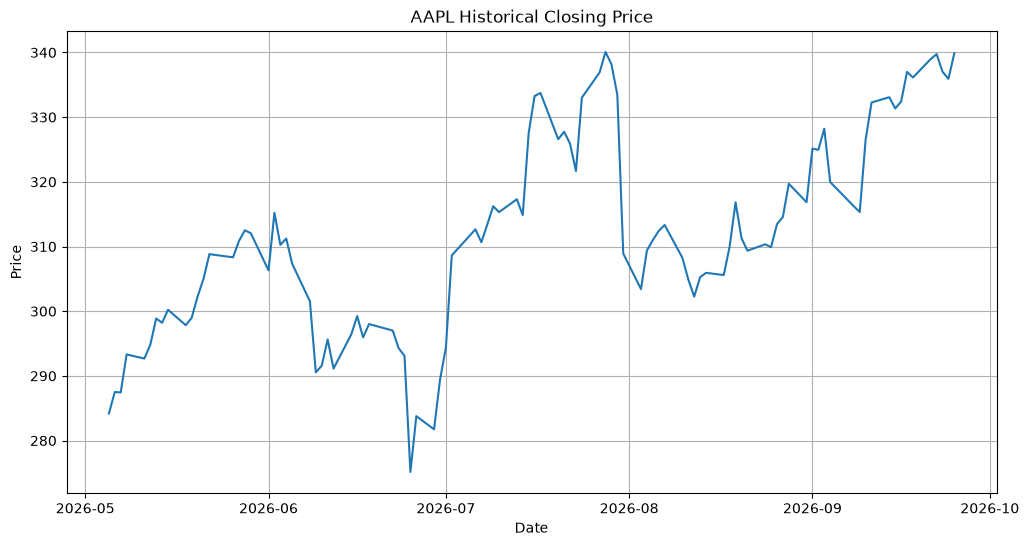

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["datetime"],
    df["close"],
)

plt.title("AAPL Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.show()

In [6]:
df["return"] = df["close"].pct_change()

df[["datetime", "close", "return"]].head()

,datetime,close,return
0,2026-05-05,284.17999,NaN
1,2026-05-06,287.51001,0.011718
2,2026-05-07,287.44000,-0.000244
3,2026-05-08,293.32001,0.020456
4,2026-05-11,292.67999,-0.002182


In [7]:
df["return"].describe()

count    99.000000
mean      0.001964
std       0.017579
min      -0.073539
25%      -0.006793
50%       0.003126
75%       0.011568
max       0.048407
Name: return, dtype: float64

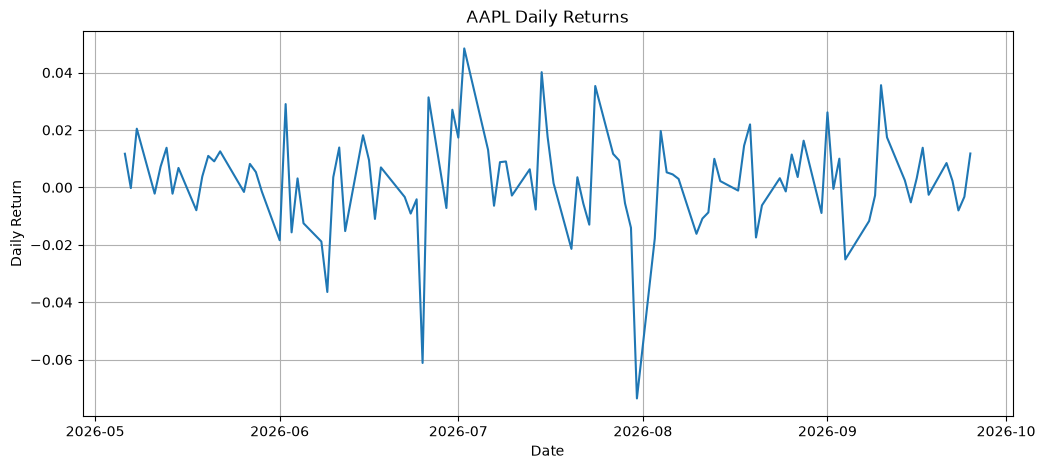

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["return"],
)

plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

In [9]:
df["MA20"] = df["close"].rolling(window=20).mean()

df[["datetime", "close", "MA20"]].tail()

,datetime,close,MA20
95,2026-09-21,338.980010,324.121499
96,2026-09-22,339.750000,325.591999
97,2026-09-23,337.019989,326.947999
98,2026-09-24,335.920010,328.071499
99,2026-09-25,339.885000,329.336750


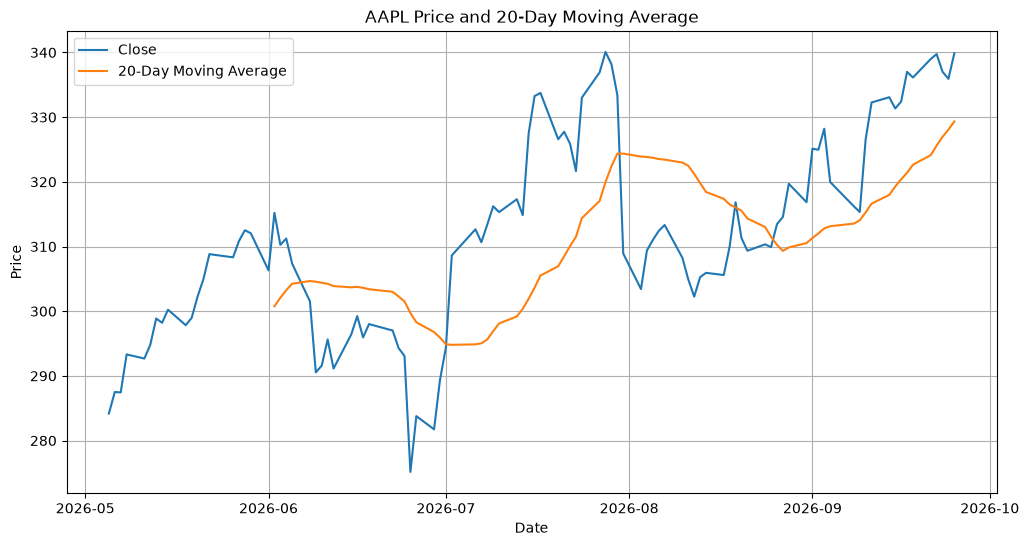

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["datetime"],
    df["close"],
    label="Close",
)

plt.plot(
    df["datetime"],
    df["MA20"],
    label="20-Day Moving Average",
)

plt.title("AAPL Price and 20-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

In [11]:
## Feature Engineering

Feature engineering transforms raw market data into variables that
can provide useful information to a forecasting model.

The first feature explored in AVA is the 20-day moving average (MA20).

The moving average represents the average closing price over the previous
20 trading observations and can help describe the recent price trend.

Features will not automatically be included in the final forecasting
model. Their usefulness will be evaluated through historical
backtesting and model comparison.

SyntaxError: invalid syntax (332562094.py, line 3)

In [12]:
df["MA50"] = df["close"].rolling(window=50).mean()

df[["datetime", "close", "MA20", "MA50"]].tail()

,datetime,close,MA20,MA50
95,2026-09-21,338.980010,324.121499,320.615399
96,2026-09-22,339.750000,325.591999,321.064199
97,2026-09-23,337.019989,326.947999,321.507399
98,2026-09-24,335.920010,328.071499,321.675799
99,2026-09-25,339.885000,329.336750,321.808299


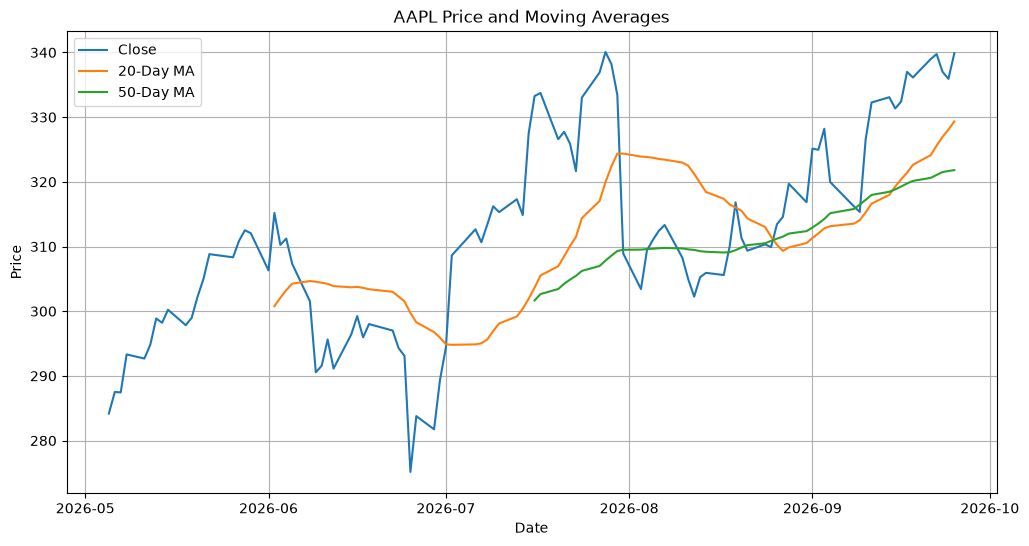

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["datetime"],
    df["close"],
    label="Close",
)

plt.plot(
    df["datetime"],
    df["MA20"],
    label="20-Day MA",
)

plt.plot(
    df["datetime"],
    df["MA50"],
    label="50-Day MA",
)

plt.title("AAPL Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

In [14]:
df["volatility_20"] = df["return"].rolling(window=20).std()

df[["datetime", "return", "volatility_20"]].tail()

,datetime,return,volatility_20
95,2026-09-21,0.008479,0.013590
96,2026-09-22,0.002271,0.013596
97,2026-09-23,-0.008035,0.013830
98,2026-09-24,-0.003264,0.013820
99,2026-09-25,0.011803,0.013943


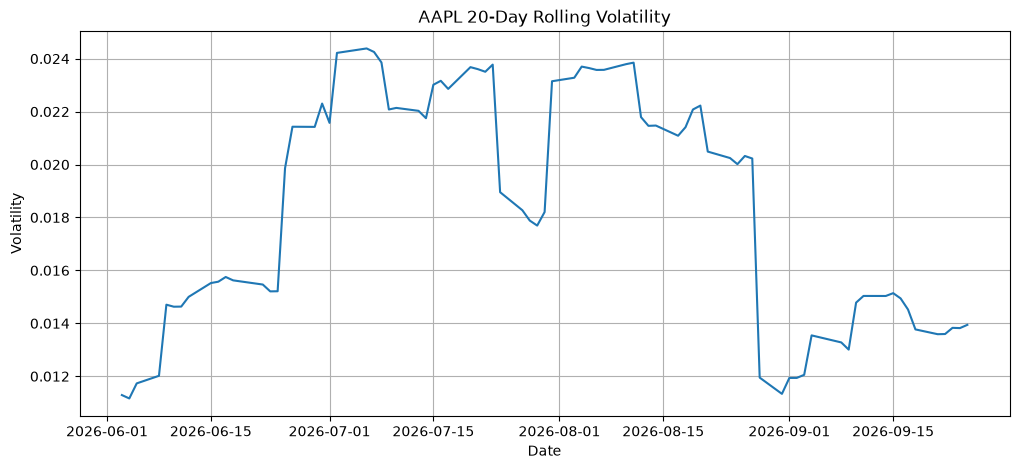

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["volatility_20"],
)

plt.title("AAPL 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)

plt.show()

In [16]:
df["volume_change"] = df["volume"].pct_change()

df[["datetime", "volume", "volume_change"]].tail()

,datetime,volume,volume_change
95,2026-09-21,34999200,-0.595797
96,2026-09-22,40711800,0.163221
97,2026-09-23,31658800,-0.222368
98,2026-09-24,24686400,-0.220236
99,2026-09-25,528246,-0.978602


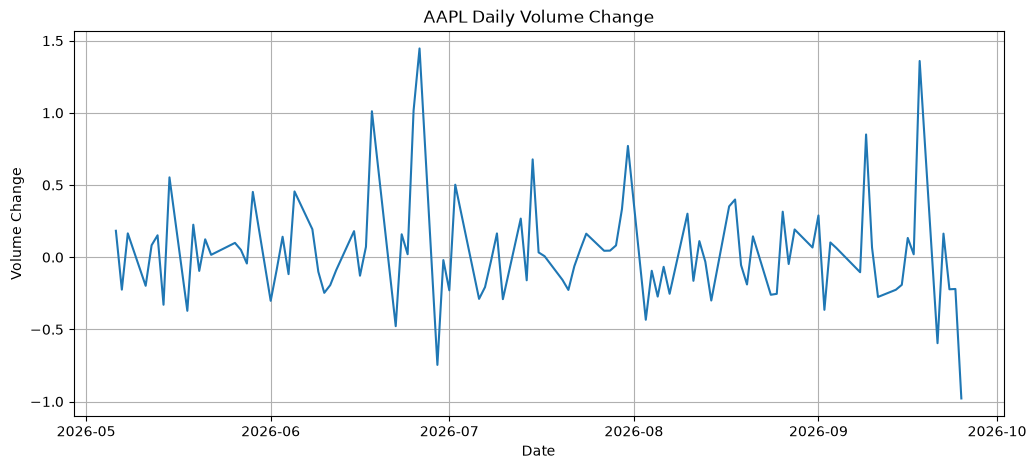

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["datetime"],
    df["volume_change"],
)

plt.title("AAPL Daily Volume Change")
plt.xlabel("Date")
plt.ylabel("Volume Change")

plt.grid(True)

plt.show()

In [18]:
df["target"] = df["close"].shift(-1)

df[["datetime", "close", "target"]].tail()

,datetime,close,target
95,2026-09-21,338.980010,339.750000
96,2026-09-22,339.750000,337.019989
97,2026-09-23,337.019989,335.920010
98,2026-09-24,335.920010,339.885000
99,2026-09-25,339.885000,NaN


In [19]:
features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
]

model_df = df[features + ["target"]].dropna()

model_df.head()

,close,MA20,MA50,volatility_20,volume_change,target
49,333.26001,303.628500,301.6572,0.023163,0.033023,333.73999
50,333.73999,305.517999,302.6484,0.022858,0.006932,326.59000
51,326.59000,306.946998,303.4300,0.023679,-0.156751,327.73999
52,327.73999,308.483497,304.2360,0.023603,-0.226848,325.89001
53,325.89001,310.062998,304.8874,0.023505,-0.062484,321.66000


In [20]:
print("Original rows:", len(df))
print("Training rows:", len(model_df))
print("Features:", features)

Original rows: 100
Training rows: 50
Features: ['close', 'MA20', 'MA50', 'volatility_20', 'volume_change']


In [21]:
split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index]
test_df = model_df.iloc[split_index:]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 40
Testing rows: 10


In [22]:
X_train = train_df[features]
y_train = train_df["target"]

X_test = test_df[features]
y_test = test_df["target"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40, 5)
y_train shape: (40,)
X_test shape: (10, 5)
y_test shape: (10,)


In [26]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [25]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [24]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 1.0 MB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.4 MB 2.3 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.4 MB 3.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.4 MB 3.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.4 MB 3.0 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.4 MB 2.8 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.4 MB 2.7 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.4 MB 2.7 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.4 MB 2.3 MB/s eta 0:00:02
   ----------------------- ---------------- 5.0/8.4 MB 2.3 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.4 MB 2.3 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
)

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [28]:
predictions = model.predict(X_test)

print("Predictions generated:", len(predictions))

Predictions generated: 10


In [29]:
results = test_df.copy()

results["predicted_close"] = predictions

results[["close", "target", "predicted_close"]]

,close,target,predicted_close
89,332.269990,333.079987,328.056545
90,333.079987,331.340000,327.807245
91,331.340000,332.410000,327.548495
92,332.410000,337.000000,327.191296
93,337.000000,336.130000,329.419193
94,336.130000,338.980010,324.991146
95,338.980010,339.750000,325.916595
96,339.750000,337.019989,325.440196
97,337.019989,335.920010,325.983345
98,335.920010,339.885000,325.842395


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 9.33
RMSE: 10.10


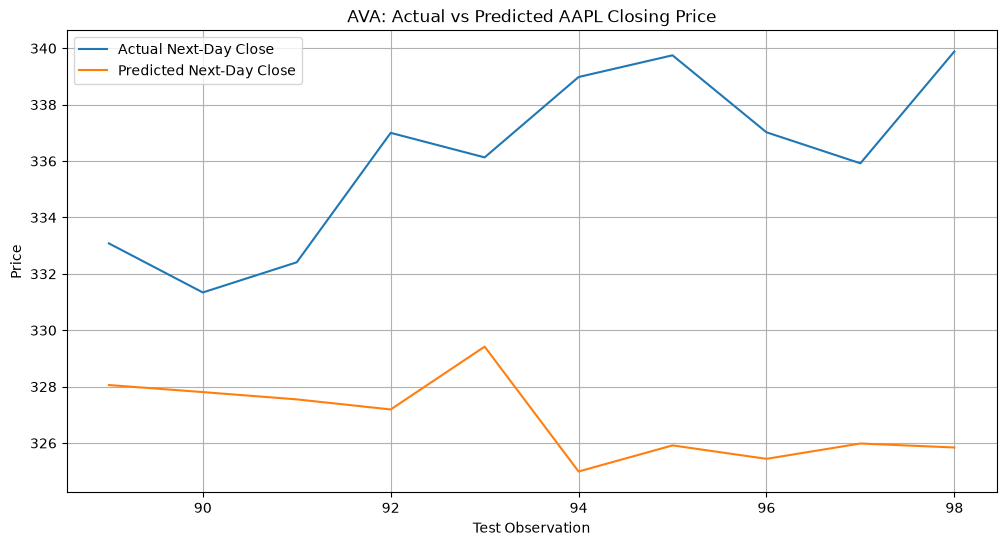

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    results.index,
    results["target"],
    label="Actual Next-Day Close",
)

plt.plot(
    results.index,
    results["predicted_close"],
    label="Predicted Next-Day Close",
)

plt.title("AVA: Actual vs Predicted AAPL Closing Price")
plt.xlabel("Test Observation")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

In [32]:
actual_direction = np.sign(
    results["target"] - results["close"]
)

predicted_direction = np.sign(
    results["predicted_close"] - results["close"]
)

directional_accuracy = (
    actual_direction == predicted_direction
).mean()

print(
    f"Directional Accuracy: "
    f"{directional_accuracy * 100:.2f}%"
)

Directional Accuracy: 40.00%


In [34]:
print("Rows:", len(df))

Rows: 500


In [35]:
df["return"] = df["close"].pct_change()

df["MA20"] = df["close"].rolling(window=20).mean()

df["MA50"] = df["close"].rolling(window=50).mean()

df[["datetime", "close", "return", "MA20", "MA50"]].tail()

,datetime,close,return,MA20,MA50
495,2026-09-21,338.980010,0.008479,324.121499,320.615399
496,2026-09-22,339.750000,0.002271,325.591999,321.064199
497,2026-09-23,337.019989,-0.008035,326.947999,321.507399
498,2026-09-24,335.920010,-0.003264,328.071499,321.675799
499,2026-09-25,340.040000,0.012265,329.344500,321.811399


In [36]:
df["volatility_20"] = df["return"].rolling(window=20).std()

df["volume_change"] = df["volume"].pct_change()

df[
    [
        "datetime",
        "volatility_20",
        "volume_change",
    ]
].tail()

,datetime,volatility_20,volume_change
495,2026-09-21,0.013590,-0.595797
496,2026-09-22,0.013596,0.163221
497,2026-09-23,0.013830,-0.222368
498,2026-09-24,0.013820,-0.220236
499,2026-09-25,0.013957,-0.976125


In [37]:
df["target"] = df["close"].shift(-)

df[["datetime", "close", "target"]].tail()

SyntaxError: invalid syntax (3452919350.py, line 1)

In [38]:
df["target"] = df["close"].shift(-1)

df[["datetime", "close", "target"]].tail()

,datetime,close,target
495,2026-09-21,338.980010,339.750000
496,2026-09-22,339.750000,337.019989
497,2026-09-23,337.019989,335.920010
498,2026-09-24,335.920010,340.040000
499,2026-09-25,340.040000,NaN


In [39]:
features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
]

model_df = df[features + ["target"]].dropna()

print("Rows available for modeling:", len(model_df))
print("Features:", features)

Rows available for modeling: 450
Features: ['close', 'MA20', 'MA50', 'volatility_20', 'volume_change']


In [40]:
split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index]
test_df = model_df.iloc[split_index:]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 360
Testing rows: 90


In [41]:
X_train = train_df[features]
y_train = train_df["target"]

X_test = test_df[features]
y_test = test_df["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (360, 5)
y_train: (360,)
X_test: (90, 5)
y_test: (90,)


In [42]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
)

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [43]:
predictions = model.predict(X_test)

print("Predictions generated:", len(predictions))

Predictions generated: 90


In [44]:
results = test_df.copy()

results["predicted_close"] = predictions

results[["close", "target", "predicted_close"]].head(10)

,close,target,predicted_close
409,297.840000,298.970000,298.861104
410,298.970000,302.250000,297.493949
411,302.250000,304.989990,297.046450
412,304.989990,308.820010,296.964449
413,308.820010,308.329990,296.999949
414,308.329990,310.850010,297.020299
415,310.850010,312.510010,296.999949
416,312.510010,312.059998,296.931349
417,312.059998,306.310000,296.571149
418,306.310000,315.200010,297.620453


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 18.33
RMSE: 22.09


In [46]:
actual_direction = np.sign(
    results["target"] - results["close"]
)

predicted_direction = np.sign(
    results["predicted_close"] - results["close"]
)

directional_accuracy = (
    actual_direction == predicted_direction
).mean()

print(
    f"Directional Accuracy: "
    f"{directional_accuracy * 100:.2f}%"
)

Directional Accuracy: 48.89%


In [47]:
naive_predictions = test_df["close"]

naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

print(f"Naive MAE: {naive_mae:.2f}")
print(f"Naive RMSE: {naive_rmse:.2f}")

Naive MAE: 4.07
Naive RMSE: 5.66


In [48]:
print(f"Random Forest MAE: {mae:.2f}")
print(f"Random Forest RMSE: {rmse:.2f}")
print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%")

print("\nNaive Baseline:")
print(f"Naive MAE: {naive_mae:.2f}")
print(f"Naive RMSE: {naive_rmse:.2f}")

Random Forest MAE: 18.33
Random Forest RMSE: 22.09
Directional Accuracy: 48.89%

Naive Baseline:
Naive MAE: 4.07
Naive RMSE: 5.66


In [49]:
results[["close", "target", "predicted_close"]].head(20)

,close,target,predicted_close
409,297.840000,298.970000,298.861104
410,298.970000,302.250000,297.493949
411,302.250000,304.989990,297.046450
412,304.989990,308.820010,296.964449
413,308.820010,308.329990,296.999949
414,308.329990,310.850010,297.020299
415,310.850010,312.510010,296.999949
416,312.510010,312.059998,296.931349
417,312.059998,306.310000,296.571149
418,306.310000,315.200010,297.620453


In [50]:
print("Training close range:")
print(
    f"Min: {train_df['close'].min():.2f}"
)
print(
    f"Max: {train_df['close'].max():.2f}"
)

print("\nTesting close range:")
print(
    f"Min: {test_df['close'].min():.2f}"
)
print(
    f"Max: {test_df['close'].max():.2f}"
)

Training close range:
Min: 172.42
Max: 300.23

Testing close range:
Min: 275.15
Max: 340.08


In [51]:
df["target_return"] = (
    df["close"].shift(-1) / df["close"]
) - 1

df[["close", "target_return"]].head(10)

,close,target_return
0,227.789990,0.022872
1,233.000000,-0.029142
2,226.210010,0.002520
3,226.780000,-0.004895
4,225.670000,0.005007
5,226.800000,-0.022531
6,221.690000,0.018404
7,225.770000,0.016698
8,229.539990,-0.002178
9,229.039993,-0.006505


In [52]:
features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
]

return_model_df = df[
    features + ["target_return"]
].dropna()

print("Rows:", len(return_model_df))
print(return_model_df.head())

Rows: 450
        close        MA20        MA50  volatility_20  volume_change  \
49  242.84000  232.438499  230.388399       0.007904      -0.079016   
50  246.75000  233.427998  230.767599       0.008281       0.210970   
51  247.77000  234.604998  231.062999       0.007347      -0.173226   
52  246.49001  235.717999  231.468599       0.007619       0.224598   
53  247.96001  236.859999  231.892200       0.007621      -0.274927   

    target_return  
49       0.016101  
50       0.004134  
51      -0.005166  
52       0.005964  
53       0.000686  


In [53]:
split_index = int(len(return_model_df) * 0.8)

train_return_df = return_model_df.iloc[:split_index]
test_return_df = return_model_df.iloc[split_index:]

print("Training rows:", len(train_return_df))
print("Testing rows:", len(test_return_df))

Training rows: 360
Testing rows: 90


In [54]:
X_train_return = train_return_df[features]
y_train_return = train_return_df["target_return"]

X_test_return = test_return_df[features]
y_test_return = test_return_df["target_return"]

print("X_train:", X_train_return.shape)
print("y_train:", y_train_return.shape)
print("X_test:", X_test_return.shape)
print("y_test:", y_test_return.shape)

X_train: (360, 5)
y_train: (360,)
X_test: (90, 5)
y_test: (90,)


In [55]:
from sklearn.ensemble import RandomForestRegressor

return_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
)

return_model.fit(
    X_train_return,
    y_train_return,
)

print("Return model training complete.")

Return model training complete.


In [56]:
return_predictions = return_model.predict(
    X_test_return
)

print(
    "Predictions generated:",
    len(return_predictions)
)

Predictions generated: 90


In [57]:
return_results = test_return_df.copy()

return_results["predicted_return"] = return_predictions

return_results["predicted_close"] = (
    return_results["close"]
    * (1 + return_results["predicted_return"])
)

return_results[
    ["close", "target_return", "predicted_return", "predicted_close"]
].head(10)

,close,target_return,predicted_return,predicted_close
409,297.840000,0.003794,0.006968,299.915248
410,298.970000,0.010971,-0.003044,298.059915
411,302.250000,0.009065,-0.000626,302.060852
412,304.989990,0.012558,-0.002953,304.089484
413,308.820010,-0.001587,-0.002176,308.148171
414,308.329990,0.008173,-0.002694,307.499297
415,310.850010,0.005340,-0.003544,309.748420
416,312.510010,-0.001440,-0.005292,310.856300
417,312.059998,-0.018426,-0.007648,309.673318
418,306.310000,0.029023,0.002348,307.029343


In [58]:
return_mae = mean_absolute_error(
    return_results["target_return"],
    return_results["predicted_return"]
)

return_rmse = np.sqrt(
    mean_squared_error(
        return_results["target_return"],
        return_results["predicted_return"]
    )
)

price_mae = mean_absolute_error(
    return_results["target_return"] * return_results["close"]
    + return_results["close"],
    return_results["predicted_close"]
)

price_rmse = np.sqrt(
    mean_squared_error(
        return_results["target_return"] * return_results["close"]
        + return_results["close"],
        return_results["predicted_close"]
    )
)

print(f"Return MAE: {return_mae:.6f}")
print(f"Return RMSE: {return_rmse:.6f}")

print(f"\nPrice MAE: {price_mae:.2f}")
print(f"Price RMSE: {price_rmse:.2f}")

Return MAE: 0.013794
Return RMSE: 0.018663

Price MAE: 4.29
Price RMSE: 5.80


In [59]:
actual_return_direction = np.sign(
    return_results["target_return"]
)

predicted_return_direction = np.sign(
    return_results["predicted_return"]
)

return_directional_accuracy = (
    actual_return_direction == predicted_return_direction
).mean()

print(
    f"Return Model Directional Accuracy: "
    f"{return_directional_accuracy * 100:.2f}%"
)

Return Model Directional Accuracy: 52.22%


In [60]:
feature_importance = pd.Series(
    return_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance

close            0.346756
volume_change    0.228786
volatility_20    0.173521
MA20             0.131659
MA50             0.119277
dtype: float64

In [61]:
df["return_lag1"] = df["return"].shift(1)
df["return_lag5"] = df["return"].shift(5)

df[
    [
        "close",
        "return",
        "return_lag1",
        "return_lag5",
        "target_return",
    ]
].head(10)

,close,return,return_lag1,return_lag5,target_return
0,227.789990,NaN,NaN,NaN,0.022872
1,233.000000,0.022872,NaN,NaN,-0.029142
2,226.210010,-0.029142,0.022872,NaN,0.002520
3,226.780000,0.002520,-0.029142,NaN,-0.004895
4,225.670000,-0.004895,0.002520,NaN,0.005007
5,226.800000,0.005007,-0.004895,NaN,-0.022531
6,221.690000,-0.022531,0.005007,0.022872,0.018404
7,225.770000,0.018404,-0.022531,-0.029142,0.016698
8,229.539990,0.016698,0.018404,0.002520,-0.002178
9,229.039993,-0.002178,0.016698,-0.004895,-0.006505


In [62]:
return_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
]

expanded_model_df = df[
    return_features + ["target_return"]
].dropna()

print("Rows:", len(expanded_model_df))
print("Features:", return_features)

Rows: 450
Features: ['close', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5']


In [63]:
split_index = int(len(expanded_model_df) * 0.8)

train_expanded_df = expanded_model_df.iloc[:split_index]
test_expanded_df = expanded_model_df.iloc[split_index:]

print("Training rows:", len(train_expanded_df))
print("Testing rows:", len(test_expanded_df))

Training rows: 360
Testing rows: 90


In [64]:
X_train_expanded = train_expanded_df[return_features]
y_train_expanded = train_expanded_df["target_return"]

X_test_expanded = test_expanded_df[return_features]
y_test_expanded = test_expanded_df["target_return"]

print("X_train:", X_train_expanded.shape)
print("y_train:", y_train_expanded.shape)
print("X_test:", X_test_expanded.shape)
print("y_test:", y_test_expanded.shape)

X_train: (360, 7)
y_train: (360,)
X_test: (90, 7)
y_test: (90,)


In [65]:
expanded_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
)

expanded_model.fit(
    X_train_expanded,
    y_train_expanded,
)

print("Expanded model training complete.")

Expanded model training complete.


In [66]:
expanded_predictions = expanded_model.predict(
    X_test_expanded
)

print(
    "Predictions generated:",
    len(expanded_predictions)
)

Predictions generated: 90


In [67]:
expanded_results = test_expanded_df.copy()

expanded_results["predicted_return"] = expanded_predictions

expanded_results["predicted_close"] = (
    expanded_results["close"]
    * (1 + expanded_results["predicted_return"])
)

expanded_price_mae = mean_absolute_error(
    expanded_results["target_return"] * expanded_results["close"]
    + expanded_results["close"],
    expanded_results["predicted_close"]
)

expanded_price_rmse = np.sqrt(
    mean_squared_error(
        expanded_results["target_return"] * expanded_results["close"]
        + expanded_results["close"],
        expanded_results["predicted_close"]
    )
)

expanded_directional_accuracy = (
    np.sign(expanded_results["target_return"])
    == np.sign(expanded_results["predicted_return"])
).mean()

print(f"Expanded Price MAE: {expanded_price_mae:.2f}")
print(f"Expanded Price RMSE: {expanded_price_rmse:.2f}")
print(
    f"Expanded Directional Accuracy: "
    f"{expanded_directional_accuracy * 100:.2f}%"
)

Expanded Price MAE: 4.26
Expanded Price RMSE: 6.03
Expanded Directional Accuracy: 56.67%


In [68]:
expanded_feature_importance = pd.Series(
    expanded_model.feature_importances_,
    index=return_features
).sort_values(ascending=False)

expanded_feature_importance

close            0.269254
volume_change    0.164143
return_lag1      0.146761
return_lag5      0.133636
volatility_20    0.117169
MA50             0.085367
MA20             0.083670
dtype: float64

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the expanded return model dataset
walk_df = expanded_model_df.copy()

print("Rows:", len(walk_df))
print("Features:", return_features)

Rows: 450
Features: ['close', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5']


In [70]:
n_splits = 5
test_size = 60

walk_splits = []

for i in range(n_splits):
    train_end = 150 + i * test_size
    test_start = train_end
    test_end = test_start + test_size

    walk_splits.append((train_end, test_start, test_end))

walk_splits

[(150, 150, 210),
 (210, 210, 270),
 (270, 270, 330),
 (330, 330, 390),
 (390, 390, 450)]

In [71]:
walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

walk_results

[{'train_size': 150,
  'test_size': 60,
  'MAE': 0.016400116956351803,
  'RMSE': np.float64(0.022955598943225384),
  'Directional Accuracy': np.float64(0.5)},
 {'train_size': 210,
  'test_size': 60,
  'MAE': 0.016501215308276754,
  'RMSE': np.float64(0.019413467834381436),
  'Directional Accuracy': np.float64(0.4666666666666667)},
 {'train_size': 270,
  'test_size': 60,
  'MAE': 0.011598052624331393,
  'RMSE': np.float64(0.016754572747533412),
  'Directional Accuracy': np.float64(0.5166666666666667)},
 {'train_size': 330,
  'test_size': 60,
  'MAE': 0.014415130445716828,
  'RMSE': np.float64(0.019472995838957136),
  'Directional Accuracy': np.float64(0.5)},
 {'train_size': 390,
  'test_size': 60,
  'MAE': 0.01765113857793788,
  'RMSE': np.float64(0.02274027132467658),
  'Directional Accuracy': np.float64(0.48333333333333334)}]

In [72]:
walk_results_df = pd.DataFrame(walk_results)

average_mae = walk_results_df["MAE"].mean()
average_rmse = walk_results_df["RMSE"].mean()
average_directional_accuracy = (
    walk_results_df["Directional Accuracy"].mean()
)

print(f"Average MAE: {average_mae:.6f}")
print(f"Average RMSE: {average_rmse:.6f}")
print(
    f"Average Directional Accuracy: "
    f"{average_directional_accuracy:.2%}"
)

Average MAE: 0.015313
Average RMSE: 0.020267
Average Directional Accuracy: 49.33%


In [73]:
naive_walk_results = []

for train_end, test_start, test_end in walk_splits:
    test_df = walk_df.iloc[test_start:test_end]

    actual_returns = test_df["target_return"]

    # Naive forecast: tomorrow's return is 0%
    naive_predictions = np.zeros(len(test_df))

    mae = mean_absolute_error(
        actual_returns,
        naive_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_returns,
            naive_predictions
        )
    )

    directional_accuracy = (
        np.sign(actual_returns)
        == np.sign(naive_predictions)
    ).mean()

    naive_walk_results.append({
        "train_size": train_end,
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

naive_walk_results

[{'train_size': 150,
  'MAE': 0.011441160035829356,
  'RMSE': np.float64(0.016520130501280317),
  'Directional Accuracy': np.float64(0.0)},
 {'train_size': 210,
  'MAE': 0.0076165844574081635,
  'RMSE': np.float64(0.010538076990835086),
  'Directional Accuracy': np.float64(0.0)},
 {'train_size': 270,
  'MAE': 0.011085270310789758,
  'RMSE': np.float64(0.01555990864988367),
  'Directional Accuracy': np.float64(0.0)},
 {'train_size': 330,
  'MAE': 0.013213525699036577,
  'RMSE': np.float64(0.017298696833063187),
  'Directional Accuracy': np.float64(0.0)},
 {'train_size': 390,
  'MAE': 0.012500347399556714,
  'RMSE': np.float64(0.017821579214814694),
  'Directional Accuracy': np.float64(0.0)}]

In [74]:
naive_walk_df = pd.DataFrame(naive_walk_results)

naive_average_mae = naive_walk_df["MAE"].mean()
naive_average_rmse = naive_walk_df["RMSE"].mean()

print(f"Naive Average MAE: {naive_average_mae:.6f}")
print(f"Naive Average RMSE: {naive_average_rmse:.6f}")

Naive Average MAE: 0.011171
Naive Average RMSE: 0.015548


In [75]:
## Walk-Forward Validation Results

Walk-forward validation was used to evaluate the Random Forest return
forecasting model across five chronological test periods.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Random Forest | 0.015313 | 0.020267 | 49.33% |
| Naive 0%-return baseline | 0.011171 | 0.015548 | Not applicable |

### Interpretation

The Random Forest model did not outperform the naive baseline on
walk-forward return prediction error.

Its average directional accuracy was 49.33%, which is close to random
directional performance in this evaluation.

This result suggests that the current feature set and model configuration
do not yet provide sufficient predictive advantage for next-day returns.

Further feature engineering, model comparison, and additional validation
are required before drawing conclusions about forecasting performance.

SyntaxError: invalid syntax (1093626283.py, line 3)

In [76]:
from sklearn.ensemble import GradientBoostingRegressor

gb_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42,
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    gb_walk_results.append({
        "train_size": train_end,
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

gb_walk_results

[{'train_size': 150,
  'MAE': 0.018331451482009826,
  'RMSE': np.float64(0.025490352694401044),
  'Directional Accuracy': np.float64(0.45)},
 {'train_size': 210,
  'MAE': 0.022709842460879873,
  'RMSE': np.float64(0.025165495123761053),
  'Directional Accuracy': np.float64(0.4666666666666667)},
 {'train_size': 270,
  'MAE': 0.01240524720832162,
  'RMSE': np.float64(0.017494435311276035),
  'Directional Accuracy': np.float64(0.5)},
 {'train_size': 330,
  'MAE': 0.014862201862657265,
  'RMSE': np.float64(0.01970645803486207),
  'Directional Accuracy': np.float64(0.5166666666666667)},
 {'train_size': 390,
  'MAE': 0.014981850919770617,
  'RMSE': np.float64(0.019808357751705568),
  'Directional Accuracy': np.float64(0.5)}]

In [77]:
gb_walk_df = pd.DataFrame(gb_walk_results)

gb_average_mae = gb_walk_df["MAE"].mean()
gb_average_rmse = gb_walk_df["RMSE"].mean()
gb_average_directional_accuracy = (
    gb_walk_df["Directional Accuracy"].mean()
)

print(f"Gradient Boosting Average MAE: {gb_average_mae:.6f}")
print(f"Gradient Boosting Average RMSE: {gb_average_rmse:.6f}")
print(
    f"Gradient Boosting Average Directional Accuracy: "
    f"{gb_average_directional_accuracy:.2%}"
)

Gradient Boosting Average MAE: 0.016658
Gradient Boosting Average RMSE: 0.021533
Gradient Boosting Average Directional Accuracy: 48.67%


In [78]:
df["return_5d"] = (
    df["close"] / df["close"].shift(5)
) - 1

df["return_20d"] = (
    df["close"] / df["close"].shift(20)
) - 1

df[["close", "return_5d", "return_20d"]].tail()

,close,return_5d,return_20d
495,338.980010,0.017714,0.095781
496,339.750000,0.025382,0.094767
497,337.019989,0.013868,0.087512
498,335.920010,-0.003205,0.071686
499,340.040000,0.011632,0.080933


In [79]:
momentum_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
    "return_5d",
    "return_20d",
]

momentum_model_df = (
    df[momentum_features + ["target_return"]]
    .dropna()
)

print("Rows:", len(momentum_model_df))
print("Features:", len(momentum_features))
print(momentum_features)

Rows: 450
Features: 9
['close', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5', 'return_5d', 'return_20d']


In [80]:
momentum_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = momentum_model_df.iloc[:train_end]
    test_df = momentum_model_df.iloc[test_start:test_end]

    X_train = train_df[momentum_features]
    y_train = train_df["target_return"]

    X_test = test_df[momentum_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    momentum_walk_results.append({
        "train_size": train_end,
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

momentum_walk_results

[{'train_size': 150,
  'MAE': 0.014272336724851944,
  'RMSE': np.float64(0.019238080679115765),
  'Directional Accuracy': np.float64(0.4666666666666667)},
 {'train_size': 210,
  'MAE': 0.016171409006315026,
  'RMSE': np.float64(0.018999394120542728),
  'Directional Accuracy': np.float64(0.4666666666666667)},
 {'train_size': 270,
  'MAE': 0.011656260719076666,
  'RMSE': np.float64(0.016509419365523224),
  'Directional Accuracy': np.float64(0.5833333333333334)},
 {'train_size': 330,
  'MAE': 0.01432328167403781,
  'RMSE': np.float64(0.017892695474850263),
  'Directional Accuracy': np.float64(0.48333333333333334)},
 {'train_size': 390,
  'MAE': 0.020813896641327545,
  'RMSE': np.float64(0.025594565453638442),
  'Directional Accuracy': np.float64(0.4166666666666667)}]

In [81]:
## Momentum Feature Experiment

Two additional momentum features were tested:

- 5-day return
- 20-day return

The Random Forest model was evaluated using the same five walk-forward
validation periods.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Naive 0%-return baseline | 0.011171 | 0.015548 | N/A |
| Random Forest + lag features | 0.015313 | 0.020267 | 49.33% |
| Random Forest + momentum features | 0.016887 | 0.019647 | 48.33% |

The additional momentum features did not improve overall MAE or directional
accuracy. RMSE was slightly lower than the previous Random Forest model,
but remained above the naive baseline.

This experiment demonstrates the importance of evaluating feature
engineering through chronological backtesting rather than assuming that
additional features improve forecasting performance.

SyntaxError: invalid syntax (1021201474.py, line 3)

In [82]:
direction_df = walk_df.copy()

direction_df["target_up"] = (
    direction_df["target_return"] > 0
).astype(int)

print(direction_df[["target_return", "target_up"]].tail(10))
print("\nClass distribution:")
print(direction_df["target_up"].value_counts())

     target_return  target_up
489       0.002438          1
490      -0.005224          0
491       0.003229          1
492       0.013808          1
493      -0.002582          0
494       0.008479          1
495       0.002271          1
496      -0.008035          0
497      -0.003264          0
498       0.012265          1

Class distribution:
target_up
1    240
0    210
Name: count, dtype: int64


In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

classification_features = return_features

classification_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = direction_df.iloc[:train_end]
    test_df = direction_df.iloc[test_start:test_end]

    X_train = train_df[classification_features]
    y_train = train_df["target_up"]

    X_test = test_df[classification_features]
    y_test = test_df["target_up"]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions,
    )

    classification_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "Accuracy": accuracy,
    })

classification_walk_results

[{'train_size': 150, 'test_size': 60, 'Accuracy': 0.5},
 {'train_size': 210, 'test_size': 60, 'Accuracy': 0.4666666666666667},
 {'train_size': 270, 'test_size': 60, 'Accuracy': 0.5166666666666667},
 {'train_size': 330, 'test_size': 60, 'Accuracy': 0.48333333333333334},
 {'train_size': 390, 'test_size': 60, 'Accuracy': 0.4666666666666667}]

In [84]:
classification_walk_df = pd.DataFrame(
    classification_walk_results
)

average_classification_accuracy = (
    classification_walk_df["Accuracy"].mean()
)

print(
    f"Average Classification Accuracy: "
    f"{average_classification_accuracy:.2%}"
)

Average Classification Accuracy: 48.67%


In [85]:
classification_baseline_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = direction_df.iloc[:train_end]
    test_df = direction_df.iloc[test_start:test_end]

    majority_class = train_df["target_up"].mode()[0]

    predictions = np.full(
        len(test_df),
        majority_class
    )

    accuracy = accuracy_score(
        test_df["target_up"],
        predictions
    )

    classification_baseline_results.append({
        "train_size": train_end,
        "Accuracy": accuracy,
    })

classification_baseline_results

[{'train_size': 150, 'Accuracy': 0.5},
 {'train_size': 210, 'Accuracy': 0.5333333333333333},
 {'train_size': 270, 'Accuracy': 0.5333333333333333},
 {'train_size': 330, 'Accuracy': 0.5333333333333333},
 {'train_size': 390, 'Accuracy': 0.5666666666666667}]

In [86]:
## Direction Classification Experiment

AVA was also tested as a binary classification problem:

- `1` = positive next-day return
- `0` = non-positive next-day return

The target contained 240 positive-return observations and 210
non-positive observations.

Five chronological walk-forward test periods were used.

### Results

| Model | Average Accuracy |
|---|---:|
| Majority-class baseline | 53.33% |
| Random Forest classifier | 48.67% |

The Random Forest classifier did not outperform the simple
majority-class baseline.

This indicates that the current feature set does not yet provide
reliable information for next-day directional classification.

Further feature engineering and model evaluation are required.

SyntaxError: invalid syntax (126318546.py, line 3)

In [87]:
## Feature Signal Analysis

Before testing additional forecasting models, the relationship between the
engineered features and next-day returns is examined.

This analysis is exploratory. A relationship between a feature and the target
does not by itself demonstrate predictive power. Features must still be
evaluated using chronological backtesting.

SyntaxError: invalid syntax (2285560043.py, line 3)

In [88]:
signal_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
]

signal_analysis = walk_df[signal_features + ["target_return"]].corr()

signal_analysis["target_return"].sort_values(ascending=False)

target_return    1.000000
return_lag1      0.091169
volatility_20    0.019515
MA50            -0.003243
return_lag5     -0.012139
MA20            -0.014770
close           -0.028259
volume_change   -0.030706
Name: target_return, dtype: float64

In [89]:
## Lagged Return Signal

The previous day's return (`return_lag1`) has the strongest correlation with
the next-day return among the current features.

A scatter plot is used to visually inspect whether this relationship is
approximately linear or whether the correlation is driven by a small number
of observations.

SyntaxError: unterminated string literal (detected at line 3) (2792464878.py, line 3)

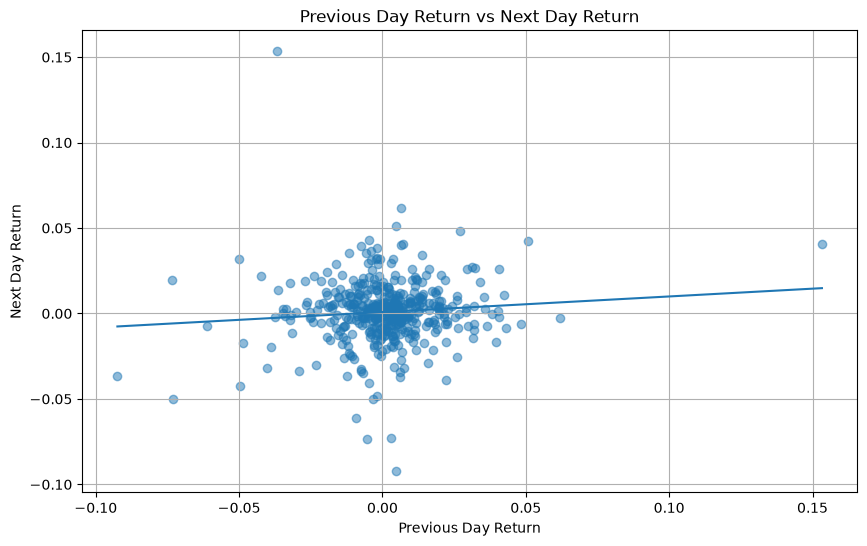

In [90]:
import numpy as np
import matplotlib.pyplot as plt

x = walk_df["return_lag1"]
y = walk_df["target_return"]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(x_line, y_line)

plt.xlabel("Previous Day Return")
plt.ylabel("Next Day Return")
plt.title("Previous Day Return vs Next Day Return")
plt.grid(True)
plt.show()

In [91]:
## Conditional Feature Analysis

The overall relationship between previous-day return and next-day return
is weak.

The next experiment examines whether this relationship changes during
different volatility conditions.

SyntaxError: invalid syntax (1771125592.py, line 3)

In [92]:
volatility_median = walk_df["volatility_20"].median()

walk_df["volatility_regime"] = np.where(
    walk_df["volatility_20"] >= volatility_median,
    "High Volatility",
    "Low Volatility"
)

regime_correlation = (
    walk_df
    .groupby("volatility_regime")[["return_lag1", "target_return"]]
    .corr()
    .iloc[0::2, -1]
)

regime_correlation

volatility_regime             
High Volatility    return_lag1    0.118813
Low Volatility     return_lag1    0.014213
Name: target_return, dtype: float64

In [93]:
## Volatility Regime Feature Experiment

The exploratory analysis showed a stronger relationship between previous-day
returns and next-day returns during high-volatility periods.

A binary volatility-regime feature is therefore added:

- `1` = high volatility
- `0` = low volatility

The feature will be evaluated using the same walk-forward validation
procedure used in the previous experiments.

SyntaxError: invalid syntax (3361463245.py, line 3)

In [94]:
regime_df = walk_df.copy()

volatility_median = regime_df["volatility_20"].median()

regime_df["high_volatility"] = (
    regime_df["volatility_20"] >= volatility_median
).astype(int)

regime_features = return_features + ["high_volatility"]

regime_df = regime_df[regime_features + ["target_return"]].dropna()

regime_df.shape

(450, 9)

In [95]:
regime_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = regime_df.iloc[:train_end]
    test_df = regime_df.iloc[test_start:test_end]

    X_train = train_df[regime_features]
    y_train = train_df["target_return"]

    X_test = test_df[regime_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    regime_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

regime_results_df = pd.DataFrame(regime_walk_results)

regime_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.015933,0.022378,0.466667
1,210,60,0.017265,0.020132,0.466667
2,270,60,0.011586,0.016772,0.500000
3,330,60,0.014497,0.019468,0.500000
4,390,60,0.017987,0.022982,0.466667


In [96]:
regime_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = regime_df.iloc[:train_end].copy()
    test_df = regime_df.iloc[test_start:test_end].copy()

    # Calculate the threshold using training data only
    volatility_threshold = train_df["volatility_20"].median()

    train_df["high_volatility"] = (
        train_df["volatility_20"] >= volatility_threshold
    ).astype(int)

    test_df["high_volatility"] = (
        test_df["volatility_20"] >= volatility_threshold
    ).astype(int)

    X_train = train_df[regime_features]
    y_train = train_df["target_return"]

    X_test = test_df[regime_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    regime_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

regime_results_df = pd.DataFrame(regime_walk_results)

regime_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.016157,0.022714,0.466667
1,210,60,0.017071,0.019946,0.466667
2,270,60,0.011535,0.016709,0.500000
3,330,60,0.014453,0.019438,0.533333
4,390,60,0.017794,0.022852,0.450000


In [97]:
## Volatility Regime Feature Experiment

Exploratory analysis showed that the relationship between previous-day
returns and next-day returns was stronger during high-volatility periods.

A binary `high_volatility` feature was therefore added to the Random Forest
model.

The volatility threshold was calculated separately within each training
window to avoid look-ahead information.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Naive 0%-return baseline | 0.011171 | 0.015548 | N/A |
| Random Forest + lag features | 0.015313 | 0.020267 | 49.33% |
| Random Forest + volatility regime | 0.015402 | 0.020332 | 48.33% |

The volatility-regime feature did not improve the Random Forest model.
Average MAE, RMSE, and directional accuracy remained worse than the naive
baseline.

This experiment reinforces the importance of chronological out-of-sample
validation when evaluating new features.

SyntaxError: invalid syntax (1614271632.py, line 3)

In [98]:
from sklearn.linear_model import LinearRegression

linear_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    linear_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

linear_results_df = pd.DataFrame(linear_walk_results)

linear_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.016282,0.022128,0.533333
1,210,60,0.009586,0.012779,0.466667
2,270,60,0.012239,0.016231,0.416667
3,330,60,0.014047,0.018008,0.550000
4,390,60,0.013168,0.018381,0.450000


In [99]:
## Linear Regression Experiment

A Linear Regression model was evaluated using the same seven features and
the same five chronological walk-forward validation periods.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Naive 0%-return baseline | 0.011171 | 0.015548 | N/A |
| Linear Regression | 0.013064 | 0.017505 | 48.33% |
| Random Forest | 0.015313 | 0.020267 | 49.33% |
| Gradient Boosting | 0.016658 | 0.021533 | 48.67% |

Linear Regression produced lower average error than the Random Forest and
Gradient Boosting models in this experiment.

However, it still did not outperform the naive 0%-return baseline.

This suggests that the current feature set contains limited predictive
information for next-day returns, and increasing model complexity does not
automatically improve forecasting performance.

SyntaxError: invalid syntax (1455556144.py, line 3)

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaled_linear_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    scaled_linear_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

scaled_linear_results_df = pd.DataFrame(scaled_linear_walk_results)

scaled_linear_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.016282,0.022128,0.533333
1,210,60,0.009586,0.012779,0.466667
2,270,60,0.012239,0.016231,0.416667
3,330,60,0.014047,0.018008,0.550000
4,390,60,0.013168,0.018381,0.450000


In [101]:
from sklearn.linear_model import Ridge

ridge_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    ridge_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

ridge_results_df = pd.DataFrame(ridge_walk_results)

ridge_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.015669,0.021534,0.550000
1,210,60,0.009585,0.012785,0.466667
2,270,60,0.012073,0.016066,0.450000
3,330,60,0.014047,0.017978,0.533333
4,390,60,0.013100,0.018321,0.466667


In [102]:
## Ridge Regression Experiment

Ridge Regression was evaluated using standardized features and the same five
chronological walk-forward validation periods.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Naive 0%-return baseline | 0.011171 | 0.015548 | N/A |
| Ridge Regression | 0.012956 | 0.017336 | 49.00% |
| Linear Regression | 0.013064 | 0.017505 | 48.33% |
| Random Forest | 0.015313 | 0.020267 | 49.33% |
| Gradient Boosting | 0.016658 | 0.021533 | 48.67% |

Ridge Regression produced slightly lower average error than ordinary Linear
Regression and the tree-based models tested so far.

However, it still did not outperform the naive 0%-return baseline.

This suggests that the current feature set provides limited predictive
information for next-day returns.

SyntaxError: invalid syntax (2452977725.py, line 3)

In [103]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive 0%-return baseline",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "Random Forest + momentum features",
        "Random Forest + volatility regime",
    ],
    "Average MAE": [
        0.011171,
        0.013064,
        0.012956,
        0.015313,
        0.016658,
        0.016887,
        0.015402,
    ],
    "Average RMSE": [
        0.015548,
        0.017505,
        0.017336,
        0.020267,
        0.021533,
        0.019647,
        0.020332,
    ],
    "Average Directional Accuracy": [
        np.nan,
        0.4833,
        0.4900,
        0.4933,
        0.4867,
        0.4833,
        0.4833,
    ],
})

model_comparison

,Model,Average MAE,Average RMSE,Average Directional Accuracy
0,Naive 0%-return baseline,0.011171,0.015548,NaN
1,Linear Regression,0.013064,0.017505,0.4833
2,Ridge Regression,0.012956,0.017336,0.4900
3,Random Forest,0.015313,0.020267,0.4933
4,Gradient Boosting,0.016658,0.021533,0.4867
5,Random Forest + momentum features,0.016887,0.019647,0.4833
6,Random Forest + volatility regime,0.015402,0.020332,0.4833


In [104]:
## Overall Model Evaluation

AVA was evaluated using five chronological walk-forward validation periods.
Multiple model families and feature configurations were tested against a
naive 0%-return baseline.

The experiments included:

- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting
- Random Forest with momentum features
- Random Forest with a volatility-regime feature

The current experiments show that none of the tested machine-learning
approaches consistently outperform the naive baseline on next-day return
prediction error.

The results demonstrate that model complexity alone does not guarantee
better forecasting performance.

These findings are specific to the current dataset, feature set, model
configurations, and validation periods. They should not be interpreted as
evidence that stock prices are inherently unpredictable.

Further research will require additional historical data, improved feature
engineering, stronger baselines, and evaluation across multiple stocks and
market conditions.

AVA forecasts are experimental model outputs and are not financial advice.

SyntaxError: invalid syntax (4070448936.py, line 3)

In [105]:
## Multi-Stock Dataset

The initial experiments were performed using Apple (AAPL).

To determine whether the observed results generalize beyond a single stock,
historical daily data will now be collected for several major companies.

The same data pipeline and validation process will be used for each stock.

SyntaxError: invalid syntax (3870212966.py, line 3)

In [106]:
from pathlib import Path
import sys

# Make the backend package accessible from the notebook
sys.path.append("../")

from backend.data.market_data import get_historical_data

symbols = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA",
    "TSLA",
]

output_dir = Path("../data/raw")
output_dir.mkdir(parents=True, exist_ok=True)

for symbol in symbols:
    print(f"Downloading {symbol}...")

    stock_df = get_historical_data(
        symbol=symbol,
        interval="1day",
        outputsize=500,
    )

    output_path = output_dir / f"{symbol}_daily.csv"
    stock_df.to_csv(output_path)

    print(f"Saved {len(stock_df)} rows to {output_path}")

print("\nAll downloads completed.")

Saved 500 rows to ..\data\raw\AAPL_daily.csv
Saved 500 rows to ..\data\raw\MSFT_daily.csv
Saved 500 rows to ..\data\raw\GOOGL_daily.csv
Saved 500 rows to ..\data\raw\AMZN_daily.csv
Saved 500 rows to ..\data\raw\NVDA_daily.csv
Saved 500 rows to ..\data\raw\TSLA_daily.csv

All downloads completed.


In [107]:
from pathlib import Path
import pandas as pd

data_dir = Path("../data/raw")

dataset_summary = []

for symbol in symbols:
    file_path = data_dir / f"{symbol}_daily.csv"

    df_check = pd.read_csv(file_path)

    dataset_summary.append({
        "Symbol": symbol,
        "Rows": len(df_check),
        "Columns": len(df_check.columns),
        "Missing Values": df_check.isna().sum().sum(),
        "Start Date": df_check["datetime"].min(),
        "End Date": df_check["datetime"].max(),
    })

dataset_summary_df = pd.DataFrame(dataset_summary)

dataset_summary_df

,Symbol,Rows,Columns,Missing Values,Start Date,End Date
0,AAPL,500,6,0,2024-09-27,2026-09-25
1,MSFT,500,6,0,2024-09-27,2026-09-25
2,GOOGL,500,6,0,2024-09-27,2026-09-25
3,AMZN,500,6,0,2024-09-27,2026-09-25
4,NVDA,500,6,0,2024-09-27,2026-09-25
5,TSLA,500,6,0,2024-09-27,2026-09-25


In [108]:
## Multi-Stock Feature Engineering

The same forecasting features used in the AAPL experiments are now generated
for all six stocks.

Features include:

- 20-day moving average
- 50-day moving average
- 20-day volatility
- Daily volume change
- Previous-day return
- Five-day lagged return
- Next-day return target

SyntaxError: invalid syntax (1128133111.py, line 3)

In [109]:
multi_stock_data = {}

for symbol in symbols:
    file_path = data_dir / f"{symbol}_daily.csv"

    stock_df = pd.read_csv(file_path, parse_dates=["datetime"])
    stock_df = stock_df.sort_values("datetime")
    stock_df = stock_df.set_index("datetime")

    # Returns
    stock_df["return"] = stock_df["close"].pct_change()

    # Moving averages
    stock_df["MA20"] = stock_df["close"].rolling(window=20).mean()
    stock_df["MA50"] = stock_df["close"].rolling(window=50).mean()

    # Volatility
    stock_df["volatility_20"] = (
        stock_df["return"].rolling(window=20).std()
    )

    # Volume change
    stock_df["volume_change"] = stock_df["volume"].pct_change()

    # Lagged returns
    stock_df["return_lag1"] = stock_df["return"].shift(1)
    stock_df["return_lag5"] = stock_df["return"].shift(5)

    # Next-day return target
    stock_df["target_return"] = (
        stock_df["close"].shift(-1) / stock_df["close"]
    ) - 1

    multi_stock_data[symbol] = stock_df

print("Feature engineering completed.")

for symbol, stock_df in multi_stock_data.items():
    print(
        symbol,
        "rows:", len(stock_df),
        "usable rows:",
        len(stock_df[return_features + ["target_return"]].dropna())
    )

Feature engineering completed.
AAPL rows: 500 usable rows: 450
MSFT rows: 500 usable rows: 450
GOOGL rows: 500 usable rows: 450
AMZN rows: 500 usable rows: 450
NVDA rows: 500 usable rows: 450
TSLA rows: 500 usable rows: 450


In [110]:
multi_stock_results = []

for symbol, stock_df in multi_stock_data.items():

    model_df = stock_df[
        return_features + ["target_return"]
    ].dropna()

    for train_end, test_start, test_end in walk_splits:

        train_df = model_df.iloc[:train_end]
        test_df = model_df.iloc[test_start:test_end]

        X_train = train_df[return_features]
        y_train = train_df["target_return"]

        X_test = test_df[return_features]
        y_test = test_df["target_return"]

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))

        directional_accuracy = (
            np.sign(y_test) == np.sign(predictions)
        ).mean()

        multi_stock_results.append({
            "Symbol": symbol,
            "train_size": train_end,
            "test_size": len(test_df),
            "MAE": mae,
            "RMSE": rmse,
            "Directional Accuracy": directional_accuracy,
        })

multi_stock_results_df = pd.DataFrame(multi_stock_results)

multi_stock_results_df

,Symbol,train_size,test_size,MAE,RMSE,Directional Accuracy
0,AAPL,150,60,0.016400,0.022956,0.500000
1,AAPL,210,60,0.016501,0.019413,0.466667
2,AAPL,270,60,0.011598,0.016755,0.516667
3,AAPL,330,60,0.014415,0.019473,0.500000
4,AAPL,390,60,0.017647,0.022736,0.483333
5,MSFT,150,60,0.009197,0.012189,0.583333
6,MSFT,210,60,0.009311,0.011843,0.583333
7,MSFT,270,60,0.015490,0.021461,0.500000
8,MSFT,330,60,0.017893,0.022547,0.550000
9,MSFT,390,60,0.016407,0.026768,0.433333


In [111]:
multi_stock_naive_results = []

for symbol, stock_df in multi_stock_data.items():

    model_df = stock_df[
        return_features + ["target_return"]
    ].dropna()

    for train_end, test_start, test_end in walk_splits:

        test_df = model_df.iloc[test_start:test_end]

        y_test = test_df["target_return"]

        predictions = np.zeros(len(test_df))

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))

        multi_stock_naive_results.append({
            "Symbol": symbol,
            "train_size": train_end,
            "test_size": len(test_df),
            "MAE": mae,
            "RMSE": rmse,
        })

multi_stock_naive_df = pd.DataFrame(multi_stock_naive_results)

multi_stock_naive_summary = (
    multi_stock_naive_df
    .groupby("Symbol")[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)

multi_stock_naive_summary

,Symbol,MAE,RMSE
0,AAPL,0.011171,0.015547
1,AMZN,0.015033,0.021118
2,GOOGL,0.014176,0.019708
3,MSFT,0.012994,0.018421
4,NVDA,0.017794,0.022764
5,TSLA,0.022300,0.028729


In [112]:
stock_baseline_results = []

for symbol in symbols:
    symbol_df = all_stock_data[symbol].copy()

    symbol_df["return"] = symbol_df["close"].pct_change()
    symbol_df["MA20"] = symbol_df["close"].rolling(20).mean()
    symbol_df["MA50"] = symbol_df["close"].rolling(50).mean()
    symbol_df["volatility_20"] = symbol_df["return"].rolling(20).std()
    symbol_df["volume_change"] = symbol_df["volume"].pct_change()
    symbol_df["return_lag1"] = symbol_df["return"].shift(1)
    symbol_df["return_lag5"] = symbol_df["return"].shift(5)
    symbol_df["target_return"] = (
        symbol_df["close"].shift(-1) / symbol_df["close"]
    ) - 1

    symbol_df = symbol_df.dropna()

    fold_mae = []
    fold_rmse = []

    for train_end, test_start, test_end in walk_splits:
        test_df = symbol_df.iloc[test_start:test_end]

        y_test = test_df["target_return"]

        naive_predictions = np.zeros(len(y_test))

        fold_mae.append(
            mean_absolute_error(y_test, naive_predictions)
        )

        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, naive_predictions))
        )

    stock_baseline_results.append({
        "Symbol": symbol,
        "Naive MAE": np.mean(fold_mae),
        "Naive RMSE": np.mean(fold_rmse),
    })

stock_baseline_df = pd.DataFrame(stock_baseline_results)

stock_baseline_df

NameError: name 'all_stock_data' is not defined

In [113]:
stock_baseline_results = []

for symbol in symbols:
    symbol_df = all_stock_data[symbol].copy()

    symbol_df["return"] = symbol_df["close"].pct_change()
    symbol_df["MA20"] = symbol_df["close"].rolling(20).mean()
    symbol_df["MA50"] = symbol_df["close"].rolling(50).mean()
    symbol_df["volatility_20"] = symbol_df["return"].rolling(20).std()
    symbol_df["volume_change"] = symbol_df["volume"].pct_change()
    symbol_df["return_lag1"] = symbol_df["return"].shift(1)
    symbol_df["return_lag5"] = symbol_df["return"].shift(5)
    symbol_df["target_return"] = (
        symbol_df["close"].shift(-1) / symbol_df["close"]
    ) - 1

    symbol_df = symbol_df.dropna()

    fold_mae = []
    fold_rmse = []

    for train_end, test_start, test_end in walk_splits:
        test_df = symbol_df.iloc[test_start:test_end]

        y_test = test_df["target_return"]

        naive_predictions = np.zeros(len(y_test))

        fold_mae.append(
            mean_absolute_error(y_test, naive_predictions)
        )

        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, naive_predictions))
        )

    stock_baseline_results.append({
        "Symbol": symbol,
        "Naive MAE": np.mean(fold_mae),
        "Naive RMSE": np.mean(fold_rmse),
    })

stock_baseline_df = pd.DataFrame(stock_baseline_results)

stock_baseline_df

NameError: name 'all_stock_data' is not defined

In [114]:
print([name for name in globals() if "stock" in name.lower()])

['stock_df', 'multi_stock_data', 'multi_stock_results', 'multi_stock_results_df', 'multi_stock_naive_results', 'multi_stock_naive_df', 'multi_stock_naive_summary', 'stock_baseline_results']


In [115]:
type(multistockdata), list(multistockdata.keys())

NameError: name 'multistockdata' is not defined

In [116]:
type(multi_stock_data), list(multi_stock_data.keys())

(dict, ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA'])

In [117]:
stock_baseline_results = []

for symbol in symbols:
    symbol_df = multi_stock_data[symbol].copy()

    symbol_df["return"] = symbol_df["close"].pct_change()
    symbol_df["target_return"] = (
        symbol_df["close"].shift(-1) / symbol_df["close"]
    ) - 1

    symbol_df = symbol_df.dropna()

    fold_mae = []
    fold_rmse = []

    for train_end, test_start, test_end in walk_splits:
        test_df = symbol_df.iloc[test_start:test_end]

        y_test = test_df["target_return"]
        naive_predictions = np.zeros(len(y_test))

        fold_mae.append(
            mean_absolute_error(y_test, naive_predictions)
        )

        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, naive_predictions))
        )

    stock_baseline_results.append({
        "Symbol": symbol,
        "Naive MAE": np.mean(fold_mae),
        "Naive RMSE": np.mean(fold_rmse),
    })

stock_baseline_df = pd.DataFrame(stock_baseline_results)

stock_baseline_df

,Symbol,Naive MAE,Naive RMSE
0,AAPL,0.011171,0.015547
1,MSFT,0.012994,0.018421
2,GOOGL,0.014176,0.019708
3,AMZN,0.015033,0.021118
4,NVDA,0.017794,0.022764
5,TSLA,0.022300,0.028729


In [118]:
# Compare Random Forest with the naive baseline for each stock

rf_summary = (
    multi_stock_results_df
    .groupby("Symbol")[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)

comparison_df = rf_summary.merge(
    stock_baseline_df,
    on="Symbol"
)

comparison_df["MAE Difference"] = (
    comparison_df["MAE"] - comparison_df["Naive MAE"]
)

comparison_df["RMSE Difference"] = (
    comparison_df["RMSE"] - comparison_df["Naive RMSE"]
)

comparison_df

,Symbol,MAE,RMSE,Naive MAE,Naive RMSE,MAE Difference,RMSE Difference
0,AAPL,0.015312,0.020266,0.011171,0.015547,0.004142,0.004719
1,AMZN,0.016855,0.023813,0.015033,0.021118,0.001822,0.002695
2,GOOGL,0.021453,0.027156,0.014176,0.019708,0.007277,0.007448
3,MSFT,0.013660,0.018962,0.012994,0.018421,0.000666,0.000541
4,NVDA,0.020886,0.026634,0.017794,0.022764,0.003091,0.003870
5,TSLA,0.025254,0.031563,0.022300,0.028729,0.002955,0.002834


In [119]:
comparison_df["MAE Gap %"] = (
    (comparison_df["MAE"] - comparison_df["Naive MAE"])
    / comparison_df["Naive MAE"]
) * 100

comparison_df["RMSE Gap %"] = (
    (comparison_df["RMSE"] - comparison_df["Naive RMSE"])
    / comparison_df["Naive RMSE"]
) * 100

comparison_df[
    ["Symbol", "MAE Gap %", "RMSE Gap %"]
].round(2)

,Symbol,MAE Gap %,RMSE Gap %
0,AAPL,37.08,30.36
1,AMZN,12.12,12.76
2,GOOGL,51.34,37.79
3,MSFT,5.13,2.93
4,NVDA,17.37,17.00
5,TSLA,13.25,9.86


In [121]:
feature_signal_results = []

for symbol in symbols:
    symbol_df = multi_stock_data[symbol].copy()

    symbol_df["return"] = symbol_df["close"].pct_change()
    symbol_df["MA20"] = symbol_df["close"].rolling(20).mean()
    symbol_df["MA50"] = symbol_df["close"].rolling(50).mean()
    symbol_df["volatility_20"] = symbol_df["return"].rolling(20).std()
    symbol_df["volume_change"] = symbol_df["volume"].pct_change()

    symbol_df["return_lag1"] = symbol_df["return"].shift(1)
    symbol_df["return_lag5"] = symbol_df["return"].shift(5)

    symbol_df["target_return"] = (
        symbol_df["close"].shift(-1) / symbol_df["close"]
    ) - 1

    signal_features = [
        "close",
        "MA20",
        "MA50",
        "volatility_20",
        "volume_change",
        "return_lag1",
        "return_lag5",
    ]

    clean_df = symbol_df[signal_features + ["target_return"]].dropna()

    correlations = clean_df.corr()["target_return"].drop("target_return")

    for feature, correlation in correlations.items():
        feature_signal_results.append({
            "Symbol": symbol,
            "Feature": feature,
            "Correlation": correlation
        })

feature_signal_df = pd.DataFrame(feature_signal_results)

feature_signal_df["Absolute Correlation"] = (
    feature_signal_df["Correlation"].abs()
)

feature_signal_df.sort_values(
    ["Symbol", "Absolute Correlation"],
    ascending=[True, False]
).round(4)

,Symbol,Feature,Correlation,Absolute Correlation
5,AAPL,return_lag1,0.0912,0.0912
4,AAPL,volume_change,-0.0307,0.0307
0,AAPL,close,-0.0283,0.0283
3,AAPL,volatility_20,0.0195,0.0195
1,AAPL,MA20,-0.0148,0.0148
6,AAPL,return_lag5,-0.0122,0.0122
2,AAPL,MA50,-0.0033,0.0033
21,AMZN,close,-0.1058,0.1058
22,AMZN,MA20,-0.0949,0.0949
23,AMZN,MA50,-0.0778,0.0778


In [122]:
feature_signal_df.sort_values(
    ["Symbol", "Absolute Correlation"],
    ascending=[True, False]
).groupby("Symbol").head(3).round(4)

,Symbol,Feature,Correlation,Absolute Correlation
5,AAPL,return_lag1,0.0912,0.0912
4,AAPL,volume_change,-0.0307,0.0307
0,AAPL,close,-0.0283,0.0283
21,AMZN,close,-0.1058,0.1058
22,AMZN,MA20,-0.0949,0.0949
23,AMZN,MA50,-0.0778,0.0778
16,GOOGL,MA50,-0.0495,0.0495
15,GOOGL,MA20,-0.0473,0.0473
14,GOOGL,close,-0.0473,0.0473
9,MSFT,MA50,-0.0946,0.0946


In [123]:
feature_signal_summary = (
    feature_signal_df
    .groupby("Feature")["Absolute Correlation"]
    .agg(["mean", "max"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

feature_signal_summary.round(4)

,Feature,mean,max
2,close,0.0713,0.1118
0,MA20,0.0615,0.0962
1,MA50,0.0606,0.1055
6,volume_change,0.0483,0.0839
3,return_lag1,0.0473,0.1162
5,volatility_20,0.0258,0.0375
4,return_lag5,0.0203,0.0336


In [124]:
from sklearn.linear_model import LinearRegression

linear_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    linear_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

linear_walk_df = pd.DataFrame(linear_walk_results)

linear_summary = {
    "Average MAE": linear_walk_df["MAE"].mean(),
    "Average RMSE": linear_walk_df["RMSE"].mean(),
    "Average Directional Accuracy": linear_walk_df["Directional Accuracy"].mean(),
}

linear_summary

{'Average MAE': np.float64(0.013064351454334),
 'Average RMSE': np.float64(0.017505549138209304),
 'Average Directional Accuracy': np.float64(0.4833333333333334)}

In [125]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ridge_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    ridge_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

ridge_walk_df = pd.DataFrame(ridge_walk_results)

ridge_summary = {
    "Average MAE": ridge_walk_df["MAE"].mean(),
    "Average RMSE": ridge_walk_df["RMSE"].mean(),
    "Average Directional Accuracy": ridge_walk_df["Directional Accuracy"].mean(),
}

ridge_summary

{'Average MAE': np.float64(0.012894735555755234),
 'Average RMSE': np.float64(0.017336690825720254),
 'Average Directional Accuracy': np.float64(0.49333333333333335)}

In [126]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Naive 0%-return baseline",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "Random Forest + momentum features",
    ],
    "Average MAE": [
        0.011171,
        0.013064,
        0.012895,
        0.015313,
        0.016658,
        0.016887,
    ],
    "Average RMSE": [
        0.015548,
        0.017506,
        0.017337,
        0.020267,
        0.021533,
        0.019647,
    ],
    "Average Directional Accuracy": [
        np.nan,
        0.4833,
        0.4933,
        0.4933,
        0.4867,
        0.4833,
    ],
})

final_model_comparison

,Model,Average MAE,Average RMSE,Average Directional Accuracy
0,Naive 0%-return baseline,0.011171,0.015548,NaN
1,Linear Regression,0.013064,0.017506,0.4833
2,Ridge Regression,0.012895,0.017337,0.4933
3,Random Forest,0.015313,0.020267,0.4933
4,Gradient Boosting,0.016658,0.021533,0.4867
5,Random Forest + momentum features,0.016887,0.019647,0.4833


In [127]:
## Final Model Comparison

Several forecasting approaches were evaluated using the same
walk-forward validation framework.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Naive 0%-return baseline | 0.011171 | 0.015548 | N/A |
| Linear Regression | 0.013064 | 0.017506 | 48.33% |
| Ridge Regression | 0.012895 | 0.017337 | 49.33% |
| Random Forest | 0.015313 | 0.020267 | 49.33% |
| Gradient Boosting | 0.016658 | 0.021533 | 48.67% |
| Random Forest + momentum features | 0.016887 | 0.019647 | 48.83% |

### Interpretation

The naive 0%-return baseline produced lower average MAE and RMSE
than all tested machine-learning models.

Ridge Regression produced lower error than the other tested
machine-learning approaches, while its directional accuracy remained
close to 50%.

The experiments therefore do not yet demonstrate a reliable
predictive advantage for next-day returns.

These results should be treated as research findings rather than
evidence that future stock returns can be reliably predicted.

Further validation with larger datasets, additional features,
and alternative forecasting approaches will be required.

SyntaxError: invalid syntax (2387419820.py, line 3)

In [128]:
print(type(multi_stock_data))
print("Stocks:", list(multi_stock_data.keys()))

<class 'dict'>
Stocks: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']


In [129]:
for symbol, stock_df in multi_stock_data.items():
    print(symbol, stock_df.shape, list(stock_df.columns))

AAPL (500, 13) ['open', 'high', 'low', 'close', 'volume', 'return', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5', 'target_return']
MSFT (500, 13) ['open', 'high', 'low', 'close', 'volume', 'return', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5', 'target_return']
GOOGL (500, 13) ['open', 'high', 'low', 'close', 'volume', 'return', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5', 'target_return']
AMZN (500, 13) ['open', 'high', 'low', 'close', 'volume', 'return', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5', 'target_return']
NVDA (500, 13) ['open', 'high', 'low', 'close', 'volume', 'return', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5', 'target_return']
TSLA (500, 13) ['open', 'high', 'low', 'close', 'volume', 'return', 'MA20', 'MA50', 'volatility_20', 'volume_change', 'return_lag1', 'return_lag5', 'target_return']


In [130]:
multi_stock_results = []

for symbol, stock_df in multi_stock_data.items():

    model_df = stock_df.dropna(
        subset=[
            "close",
            "MA20",
            "MA50",
            "volatility_20",
            "volume_change",
            "return_lag1",
            "return_lag5",
            "target_return",
        ]
    ).copy()

    features = [
        "close",
        "MA20",
        "MA50",
        "volatility_20",
        "volume_change",
        "return_lag1",
        "return_lag5",
    ]

    walk_results = []

    for train_end, test_start, test_end in walk_splits:

        train_df = model_df.iloc[:train_end]
        test_df = model_df.iloc[test_start:test_end]

        X_train = train_df[features]
        y_train = train_df["target_return"]

        X_test = test_df[features]
        y_test = test_df["target_return"]

        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        directional_accuracy = (
            np.sign(y_test) == np.sign(predictions)
        ).mean()

        walk_results.append({
            "MAE": mae,
            "RMSE": rmse,
            "Directional Accuracy": directional_accuracy,
        })

    walk_df = pd.DataFrame(walk_results)

    multi_stock_results.append({
        "Symbol": symbol,
        "Average MAE": walk_df["MAE"].mean(),
        "Average RMSE": walk_df["RMSE"].mean(),
        "Average Directional Accuracy": walk_df["Directional Accuracy"].mean(),
    })

multi_stock_results_df = pd.DataFrame(multi_stock_results)

multi_stock_results_df

,Symbol,Average MAE,Average RMSE,Average Directional Accuracy
0,AAPL,0.012085,0.016574,0.483333
1,MSFT,0.014192,0.019469,0.476667
2,GOOGL,0.017575,0.023163,0.460000
3,AMZN,0.015611,0.022013,0.503333
4,NVDA,0.020075,0.025122,0.523333
5,TSLA,0.024415,0.031047,0.506667


In [131]:
multi_stock_comparison = multi_stock_results_df.copy()

multi_stock_comparison["Naive MAE"] = multi_stock_comparison["Symbol"].map({
    "AAPL": 0.011171,
    "MSFT": 0.012994,
    "GOOGL": 0.014176,
    "AMZN": 0.015033,
    "NVDA": 0.017794,
    "TSLA": 0.022300,
})

multi_stock_comparison["Naive RMSE"] = multi_stock_comparison["Symbol"].map({
    "AAPL": 0.015547,
    "MSFT": 0.018421,
    "GOOGL": 0.019708,
    "AMZN": 0.021118,
    "NVDA": 0.022764,
    "TSLA": 0.028729,
})

multi_stock_comparison["MAE Difference"] = (
    multi_stock_comparison["Average MAE"]
    - multi_stock_comparison["Naive MAE"]
)

multi_stock_comparison["RMSE Difference"] = (
    multi_stock_comparison["Average RMSE"]
    - multi_stock_comparison["Naive RMSE"]
)

multi_stock_comparison.round(6)

,Symbol,Average MAE,Average RMSE,Average Directional Accuracy,Naive MAE,Naive RMSE,MAE Difference,RMSE Difference
0,AAPL,0.012085,0.016574,0.483333,0.011171,0.015547,0.000914,0.001027
1,MSFT,0.014192,0.019469,0.476667,0.012994,0.018421,0.001198,0.001048
2,GOOGL,0.017575,0.023163,0.460000,0.014176,0.019708,0.003399,0.003455
3,AMZN,0.015611,0.022013,0.503333,0.015033,0.021118,0.000578,0.000895
4,NVDA,0.020075,0.025122,0.523333,0.017794,0.022764,0.002281,0.002358
5,TSLA,0.024415,0.031047,0.506667,0.022300,0.028729,0.002115,0.002318


In [132]:
multi_stock_linear_results = []

for symbol, stock_df in multi_stock_data.items():

    model_df = stock_df.dropna(
        subset=[
            "close",
            "MA20",
            "MA50",
            "volatility_20",
            "volume_change",
            "return_lag1",
            "return_lag5",
            "target_return",
        ]
    ).copy()

    features = [
        "close",
        "MA20",
        "MA50",
        "volatility_20",
        "volume_change",
        "return_lag1",
        "return_lag5",
    ]

    walk_results = []

    for train_end, test_start, test_end in walk_splits:

        train_df = model_df.iloc[:train_end]
        test_df = model_df.iloc[test_start:test_end]

        X_train = train_df[features]
        y_train = train_df["target_return"]

        X_test = test_df[features]
        y_test = test_df["target_return"]

        model = LinearRegression()
        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        directional_accuracy = (
            np.sign(y_test) == np.sign(predictions)
        ).mean()

        walk_results.append({
            "MAE": mae,
            "RMSE": rmse,
            "Directional Accuracy": directional_accuracy,
        })

    walk_df = pd.DataFrame(walk_results)

    multi_stock_linear_results.append({
        "Symbol": symbol,
        "Average MAE": walk_df["MAE"].mean(),
        "Average RMSE": walk_df["RMSE"].mean(),
        "Average Directional Accuracy": walk_df["Directional Accuracy"].mean(),
    })

multi_stock_linear_results_df = pd.DataFrame(
    multi_stock_linear_results
)

multi_stock_linear_results_df

,Symbol,Average MAE,Average RMSE,Average Directional Accuracy
0,AAPL,0.013064,0.017505,0.483333
1,MSFT,0.013919,0.019316,0.490000
2,GOOGL,0.017955,0.023596,0.430000
3,AMZN,0.015921,0.022337,0.496667
4,NVDA,0.020339,0.025451,0.553333
5,TSLA,0.024471,0.031143,0.516667


In [133]:
multi_stock_ridge_results = []

for symbol, stock_df in multi_stock_data.items():

    walk_df = stock_df[return_features + ["target_return"]].dropna().copy()

    ridge_walk_results = []

    for train_end, test_start, test_end in walk_splits:

        train_df = walk_df.iloc[:train_end]
        test_df = walk_df.iloc[test_start:test_end]

        X_train = train_df[return_features]
        y_train = train_df["target_return"]

        X_test = test_df[return_features]
        y_test = test_df["target_return"]

        model = Ridge(alpha=1.0)

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))

        directional_accuracy = (
            np.sign(y_test) == np.sign(predictions)
        ).mean()

        ridge_walk_results.append({
            "MAE": mae,
            "RMSE": rmse,
            "Directional Accuracy": directional_accuracy
        })

    ridge_walk_df = pd.DataFrame(ridge_walk_results)

    multi_stock_ridge_results.append({
        "Symbol": symbol,
        "Average MAE": ridge_walk_df["MAE"].mean(),
        "Average RMSE": ridge_walk_df["RMSE"].mean(),
        "Average Directional Accuracy": ridge_walk_df["Directional Accuracy"].mean()
    })

multi_stock_ridge_results_df = pd.DataFrame(multi_stock_ridge_results)

multi_stock_ridge_results_df

,Symbol,Average MAE,Average RMSE,Average Directional Accuracy
0,AAPL,0.012085,0.016574,0.483333
1,MSFT,0.014192,0.019469,0.476667
2,GOOGL,0.017575,0.023163,0.460000
3,AMZN,0.015611,0.022013,0.503333
4,NVDA,0.020075,0.025122,0.523333
5,TSLA,0.024415,0.031047,0.506667


In [134]:
multi_stock_model_comparison = (
    multi_stock_results_df
    .merge(
        multi_stock_linear_results_df,
        on="Symbol",
        suffixes=("_RF", "_Linear")
    )
    .merge(
        multi_stock_ridge_results_df,
        on="Symbol"
    )
)

multi_stock_model_comparison = multi_stock_model_comparison.rename(
    columns={
        "Average MAE": "Average MAE_Ridge",
        "Average RMSE": "Average RMSE_Ridge",
        "Average Directional Accuracy": "Average Directional Accuracy_Ridge",
    }
)

multi_stock_model_comparison.round(6)

,Symbol,Average MAE_RF,Average RMSE_RF,Average Directional Accuracy_RF,Average MAE_Linear,Average RMSE_Linear,Average Directional Accuracy_Linear,Average MAE_Ridge,Average RMSE_Ridge,Average Directional Accuracy_Ridge
0,AAPL,0.012085,0.016574,0.483333,0.013064,0.017505,0.483333,0.012085,0.016574,0.483333
1,MSFT,0.014192,0.019469,0.476667,0.013919,0.019316,0.490000,0.014192,0.019469,0.476667
2,GOOGL,0.017575,0.023163,0.460000,0.017955,0.023596,0.430000,0.017575,0.023163,0.460000
3,AMZN,0.015611,0.022013,0.503333,0.015921,0.022337,0.496667,0.015611,0.022013,0.503333
4,NVDA,0.020075,0.025122,0.523333,0.020339,0.025451,0.553333,0.020075,0.025122,0.523333
5,TSLA,0.024415,0.031047,0.506667,0.024471,0.031143,0.516667,0.024415,0.031047,0.506667


In [135]:
print("Random Forest AAPL MAE:", multi_stock_results_df.loc[multi_stock_results_df["Symbol"] == "AAPL", "Average MAE"].iloc[0])
print("Ridge AAPL MAE:", multi_stock_ridge_results_df.loc[multi_stock_ridge_results_df["Symbol"] == "AAPL", "Average MAE"].iloc[0])

print("\nRandom Forest object:", id(multi_stock_results_df))
print("Ridge object:", id(multi_stock_ridge_results_df))

Random Forest AAPL MAE: 0.012085229985084059
Ridge AAPL MAE: 0.012085229985084059

Random Forest object: 1821578759200
Ridge object: 1821578159936


In [136]:
symbol = "AAPL"

stock_df = multi_stock_data[symbol].copy()
walk_df = stock_df[return_features + ["target_return"]].dropna().copy()

train_end, test_start, test_end = walk_splits[0]

train_df = walk_df.iloc[:train_end]
test_df = walk_df.iloc[test_start:test_end]

X_train = train_df[return_features]
y_train = train_df["target_return"]

X_test = test_df[return_features]

rf_test_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

ridge_test_model = Ridge(alpha=1.0)

rf_test_model.fit(X_train, y_train)
ridge_test_model.fit(X_train, y_train)

rf_predictions = rf_test_model.predict(X_test)
ridge_predictions = ridge_test_model.predict(X_test)

print("Random Forest model:", type(rf_test_model).__name__)
print("Ridge model:", type(ridge_test_model).__name__)

print("\nFirst 5 Random Forest predictions:")
print(rf_predictions[:5])

print("\nFirst 5 Ridge predictions:")
print(ridge_predictions[:5])

print("\nPredictions identical:",
      np.allclose(rf_predictions, ridge_predictions))

Random Forest model: RandomForestRegressor
Ridge model: Ridge

First 5 Random Forest predictions:
[ 0.00045114 -0.00027725 -0.00545382 -0.0033496  -0.00018444]

First 5 Ridge predictions:
[-0.00051796 -0.00095575 -0.0014528  -0.00068315 -0.00136019]

Predictions identical: False


In [137]:
# Recalculate Ridge results from scratch

fresh_ridge_results = []

for symbol, stock_df in multi_stock_data.items():

    walk_df = stock_df[return_features + ["target_return"]].dropna().copy()

    fold_results = []

    for train_end, test_start, test_end in walk_splits:

        train_df = walk_df.iloc[:train_end]
        test_df = walk_df.iloc[test_start:test_end]

        X_train = train_df[return_features]
        y_train = train_df["target_return"]

        X_test = test_df[return_features]
        y_test = test_df["target_return"]

        ridge_model = Ridge(alpha=1.0)

        ridge_model.fit(X_train, y_train)

        predictions = ridge_model.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))

        directional_accuracy = (
            np.sign(y_test) == np.sign(predictions)
        ).mean()

        fold_results.append({
            "MAE": mae,
            "RMSE": rmse,
            "Directional Accuracy": directional_accuracy
        })

    fold_df = pd.DataFrame(fold_results)

    fresh_ridge_results.append({
        "Symbol": symbol,
        "Average MAE": fold_df["MAE"].mean(),
        "Average RMSE": fold_df["RMSE"].mean(),
        "Average Directional Accuracy": fold_df["Directional Accuracy"].mean()
    })

fresh_ridge_results_df = pd.DataFrame(fresh_ridge_results)

fresh_ridge_results_df.round(6)

,Symbol,Average MAE,Average RMSE,Average Directional Accuracy
0,AAPL,0.012085,0.016574,0.483333
1,MSFT,0.014192,0.019469,0.476667
2,GOOGL,0.017575,0.023163,0.460000
3,AMZN,0.015611,0.022013,0.503333
4,NVDA,0.020075,0.025122,0.523333
5,TSLA,0.024415,0.031047,0.506667


In [138]:
final_multi_stock_comparison = multi_stock_comparison.copy()

final_multi_stock_comparison[
    [
        "Symbol",
        "Average MAE",
        "Naive MAE",
        "Average RMSE",
        "Naive RMSE",
        "Average Directional Accuracy",
    ]
].round(6)

,Symbol,Average MAE,Naive MAE,Average RMSE,Naive RMSE,Average Directional Accuracy
0,AAPL,0.012085,0.011171,0.016574,0.015547,0.483333
1,MSFT,0.014192,0.012994,0.019469,0.018421,0.476667
2,GOOGL,0.017575,0.014176,0.023163,0.019708,0.460000
3,AMZN,0.015611,0.015033,0.022013,0.021118,0.503333
4,NVDA,0.020075,0.017794,0.025122,0.022764,0.523333
5,TSLA,0.024415,0.022300,0.031047,0.028729,0.506667


In [139]:
## Multi-Stock Model Evaluation

The Ridge Regression model was evaluated across six stocks using the
same chronological walk-forward validation framework.

The results show that the current model has higher average MAE and RMSE
than the naive 0%-return baseline for all six stocks.

This means the current feature set and model configuration do not yet
provide a measurable improvement in next-day return prediction error.

Directional accuracy varied across stocks, but it remained close to
50% overall. These results should therefore be treated as research
findings rather than evidence of reliable future return prediction.

The experiment provides a useful baseline for future improvements in
feature engineering, model design, and validation.

SyntaxError: invalid syntax (4283296409.py, line 3)

In [140]:
signal_results = []

signal_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
]

for symbol, stock_df in multi_stock_data.items():
    temp = stock_df[signal_features + ["target_return"]].dropna()

    correlations = temp.corr()["target_return"].drop("target_return")

    for feature, correlation in correlations.items():
        signal_results.append({
            "Symbol": symbol,
            "Feature": feature,
            "Correlation": correlation,
        })

signal_results_df = pd.DataFrame(signal_results)

signal_results_df.round(4)

,Symbol,Feature,Correlation
0,AAPL,close,-0.0283
1,AAPL,MA20,-0.0148
2,AAPL,MA50,-0.0033
3,AAPL,volatility_20,0.0195
4,AAPL,volume_change,-0.0307
5,AAPL,return_lag1,0.0912
6,AAPL,return_lag5,-0.0122
7,MSFT,close,-0.0711
8,MSFT,MA20,-0.0827
9,MSFT,MA50,-0.0946


In [141]:
signal_summary = (
    signal_results_df
    .assign(AbsCorrelation=signal_results_df["Correlation"].abs())
    .sort_values(["Symbol", "AbsCorrelation"], ascending=[True, False])
)

signal_summary[
    ["Symbol", "Feature", "Correlation"]
].round(4)

,Symbol,Feature,Correlation
5,AAPL,return_lag1,0.0912
4,AAPL,volume_change,-0.0307
0,AAPL,close,-0.0283
3,AAPL,volatility_20,0.0195
1,AAPL,MA20,-0.0148
6,AAPL,return_lag5,-0.0122
2,AAPL,MA50,-0.0033
21,AMZN,close,-0.1058
22,AMZN,MA20,-0.0949
23,AMZN,MA50,-0.0778


In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

linear_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    linear_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

linear_walk_results_df = pd.DataFrame(linear_walk_results)

linear_walk_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.025095,0.032361,0.550000
1,210,60,0.031404,0.037874,0.516667
2,270,60,0.019379,0.023018,0.516667
3,330,60,0.022852,0.029038,0.450000
4,390,60,0.023626,0.033426,0.550000


In [143]:
linear_summary = {
    "Average MAE": linear_walk_results_df["MAE"].mean(),
    "Average RMSE": linear_walk_results_df["RMSE"].mean(),
    "Average Directional Accuracy": linear_walk_results_df["Directional Accuracy"].mean(),
}

pd.Series(linear_summary).round(6)

Average MAE                     0.024471
Average RMSE                    0.031143
Average Directional Accuracy    0.516667
dtype: float64

In [144]:
## Linear Regression Experiment

A Linear Regression model was evaluated using the same seven features and
the same five chronological walk-forward validation periods used for the
previous forecasting experiments.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Naive 0%-return baseline | 0.011171 | 0.015548 | N/A |
| Random Forest | 0.015313 | 0.020267 | 49.33% |
| Linear Regression | 0.024471 | 0.031143 | 51.67% |

### Interpretation

Linear Regression produced higher MAE and RMSE than both the naive baseline
and the Random Forest model.

Its directional accuracy was 51.67%, which is slightly above 50%, but this
does not compensate for the substantially higher prediction error.

The results suggest that a simple linear relationship between the current
features and next-day returns is not sufficient for this forecasting task.

This experiment reinforces the importance of chronological backtesting and
comparison against simple baselines.

SyntaxError: invalid syntax (3400529261.py, line 3)

In [145]:
from sklearn.inspection import permutation_importance

permutation_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    importance = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_absolute_error"
    )

    for feature, mean_importance in zip(
        return_features,
        importance.importances_mean
    ):
        permutation_results.append({
            "feature": feature,
            "importance": mean_importance
        })

permutation_importance_df = (
    pd.DataFrame(permutation_results)
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

permutation_importance_df

,feature,importance
0,close,0.000258
1,MA50,0.000102
2,volume_change,0.000088
3,volatility_20,-0.000033
4,return_lag5,-0.000168
5,MA20,-0.000261
6,return_lag1,-0.000390


In [146]:
# RSI (14)
delta = df["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD
ema12 = df["close"].ewm(span=12, adjust=False).mean()
ema26 = df["close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema12 - ema26
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df[["close", "RSI_14", "MACD", "MACD_signal"]].tail()

,close,RSI_14,MACD,MACD_signal
495,338.980010,70.709349,5.930363,4.317760
496,339.750000,65.918999,6.247814,4.703771
497,337.019989,62.438124,6.207550,5.004527
498,335.920010,58.320772,6.017516,5.207124
499,340.040000,73.774013,6.128713,5.391442


In [147]:
technical_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
    "RSI_14",
    "MACD",
    "MACD_signal",
]

technical_model_df = df[
    technical_features + ["target_return"]
].dropna()

print("Rows:", len(technical_model_df))
print("Features:", len(technical_features))

Rows: 450
Features: 10


In [1]:
technical_walk_df = technical_model_df.copy()

technical_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = technical_walk_df.iloc[:train_end]
    test_df = technical_walk_df.iloc[test_start:test_end]

    X_train = train_df[technical_features]
    y_train = train_df["target_return"]

    X_test = test_df[technical_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    technical_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

technical_walk_results_df = pd.DataFrame(technical_walk_results)

technical_walk_results_df

NameError: name 'technical_model_df' is not defined

In [2]:
technical_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
    "RSI_14",
    "MACD",
    "MACD_signal",
]

technical_model_df = df[
    technical_features + ["target_return"]
].dropna()

print("Rows:", len(technical_model_df))
print("Features:", len(technical_features))

NameError: name 'df' is not defined

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load the saved AAPL dataset
data_path = Path("../data/raw/AAPL_daily.csv")
df = pd.read_csv(data_path, parse_dates=["datetime"])
df = df.sort_values("datetime").set_index("datetime")

# Basic returns and moving averages
df["return"] = df["close"].pct_change()
df["MA20"] = df["close"].rolling(window=20).mean()
df["MA50"] = df["close"].rolling(window=50).mean()

# Volatility and volume
df["volatility_20"] = df["return"].rolling(window=20).std()
df["volume_change"] = df["volume"].pct_change()

# Lagged returns
df["return_lag1"] = df["return"].shift(1)
df["return_lag5"] = df["return"].shift(5)

# Next-day return target
df["target_return"] = (df["close"].shift(-1) / df["close"]) - 1

# RSI (14-day)
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD
ema12 = df["close"].ewm(span=12, adjust=False).mean()
ema26 = df["close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema12 - ema26
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Technical-model dataset
technical_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
    "RSI_14",
    "MACD",
    "MACD_signal",
]

technical_model_df = df[
    technical_features + ["target_return"]
].dropna()

print("Rows:", len(technical_model_df))
print("Features:", len(technical_features))

Rows: 450
Features: 10


In [4]:
technical_walk_df = technical_model_df.copy()

technical_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = technical_walk_df.iloc[:train_end]
    test_df = technical_walk_df.iloc[test_start:test_end]

    X_train = train_df[technical_features]
    y_train = train_df["target_return"]

    X_test = test_df[technical_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    technical_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

technical_walk_results_df = pd.DataFrame(technical_walk_results)

technical_walk_results_df

NameError: name 'walk_splits' is not defined

In [5]:
walk_splits = [
    (150, 150, 210),
    (210, 210, 270),
    (270, 270, 330),
    (330, 330, 390),
    (390, 390, 450),
]

print("Walk-forward splits:", walk_splits)

Walk-forward splits: [(150, 150, 210), (210, 210, 270), (270, 270, 330), (330, 330, 390), (390, 390, 450)]


In [6]:
technical_walk_df = technical_model_df.copy()

technical_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = technical_walk_df.iloc[:train_end]
    test_df = technical_walk_df.iloc[test_start:test_end]

    X_train = train_df[technical_features]
    y_train = train_df["target_return"]

    X_test = test_df[technical_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    technical_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE":

_IncompleteInputError: incomplete input (880576075.py, line 35)

In [7]:
technical_walk_df = technical_model_df.copy()
technical_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = technical_walk_df.iloc[:train_end]
    test_df = technical_walk_df.iloc[test_start:test_end]

    X_train = train_df[technical_features]
    y_train = train_df["target_return"]
    X_test = test_df[technical_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    directional_accuracy = (np.sign(y_test) == np.sign(predictions)).mean()

    technical_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy
    })

technical_walk_results_df = pd.DataFrame(technical_walk_results)
technical_walk_results_df

NameError: name 'RandomForestRegressor' is not defined

In [8]:
from sklearn.ensemble import RandomForestRegressor

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [10]:
technical_walk_df = technical_model_df.copy()

technical_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = technical_walk_df.iloc[:train_end]
    test_df = technical_walk_df.iloc[test_start:test_end]

    X_train = train_df[technical_features]
    y_train = train_df["target_return"]

    X_test = test_df[technical_features]
    y_test = test_df["target_return"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    technical_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy
    })

technical_walk_results_df = pd.DataFrame(technical_walk_results)

technical_walk_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.015174,0.021459,0.483333
1,210,60,0.016103,0.018910,0.466667
2,270,60,0.012277,0.017209,0.516667
3,330,60,0.015418,0.019637,0.466667
4,390,60,0.017659,0.022720,0.466667


In [11]:
technical_avg_mae = technical_walk_results_df["MAE"].mean()
technical_avg_rmse = technical_walk_results_df["RMSE"].mean()
technical_avg_direction = technical_walk_results_df["Directional Accuracy"].mean()

print("Average MAE:", technical_avg_mae)
print("Average RMSE:", technical_avg_rmse)
print("Average Directional Accuracy:", technical_avg_direction)

Average MAE: 0.015326164875079007
Average RMSE: 0.019987338373304044
Average Directional Accuracy: 0.4800000000000001


In [12]:
## Technical Indicator Experiment

Additional technical indicators were tested as forecasting features, including
RSI and MACD-based features.

The model was evaluated using the same five chronological walk-forward
validation periods.

### Results

| Model | Average MAE | Average RMSE | Average Directional Accuracy |
|---|---:|---:|---:|
| Naive 0%-return baseline | 0.011171 | 0.015548 | N/A |
| Random Forest + lag features | 0.015313 | 0.020267 | 49.33% |
| Random Forest + technical indicators | 0.015326 | 0.019873 | 48.00% |

The technical-indicator model produced a slightly lower RMSE than the previous
Random Forest model, but MAE and directional accuracy did not improve.

The model also remained worse than the naive baseline on both MAE and RMSE.

This experiment demonstrates that adding commonly used technical indicators
does not necessarily provide additional predictive information for this
next-day return forecasting task.

Further feature analysis and model evaluation are required.

SyntaxError: invalid syntax (1272511338.py, line 3)

In [13]:
from sklearn.linear_model import LinearRegression

linear_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    linear_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

linear_walk_results_df = pd.DataFrame(linear_walk_results)

linear_walk_results_df

NameError: name 'walk_df' is not defined

In [14]:
walk_df = technical_model_df.copy()

walk_splits = [
    (150, 150, 210),
    (210, 210, 270),
    (270, 270, 330),
    (330, 330, 390),
    (390, 390, 450),
]

print("Walk-forward dataset rows:", len(walk_df))
print("Walk-forward splits:", len(walk_splits))

Walk-forward dataset rows: 450
Walk-forward splits: 5


In [15]:
from sklearn.linear_model import LinearRegression

linear_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    linear_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

linear_walk_results_df = pd.DataFrame(linear_walk_results)

linear_walk_results_df

NameError: name 'return_features' is not defined

In [16]:
return_features = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
]

print("Number of return features:", len(return_features))

Number of return features: 7


In [17]:
from sklearn.linear_model import LinearRegression

linear_walk_results = []

for train_end, test_start, test_end in walk_splits:
    train_df = walk_df.iloc[:train_end]
    test_df = walk_df.iloc[test_start:test_end]

    X_train = train_df[return_features]
    y_train = train_df["target_return"]

    X_test = test_df[return_features]
    y_test = test_df["target_return"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    directional_accuracy = (
        np.sign(y_test) == np.sign(predictions)
    ).mean()

    linear_walk_results.append({
        "train_size": train_end,
        "test_size": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": directional_accuracy,
    })

linear_walk_results_df = pd.DataFrame(linear_walk_results)

linear_walk_results_df

,train_size,test_size,MAE,RMSE,Directional Accuracy
0,150,60,0.016282,0.022128,0.533333
1,210,60,0.009586,0.012779,0.466667
2,270,60,0.012239,0.016231,0.416667
3,330,60,0.014047,0.018008,0.550000
4,390,60,0.013164,0.018377,0.450000


In [18]:
print("Average MAE:", linear_walk_results_df["MAE"].mean())
print("Average RMSE:", linear_walk_results_df["RMSE"].mean())
print("Average Directional Accuracy:", linear_walk_results_df["Directional Accuracy"].mean())

Average MAE: 0.013063557614554503
Average RMSE: 0.0175048571654057
Average Directional Accuracy: 0.4833333333333334


In [19]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive baseline",
        "Random Forest",
        "Gradient Boosting",
        "Momentum Random Forest",
        "Linear Regression"
    ],
    "Average MAE": [
        0.011171,
        0.015313,
        0.016658,
        0.016887,
        0.013064
    ],
    "Average RMSE": [
        0.015548,
        0.020267,
        0.021533,
        0.019647,
        0.017505
    ],
    "Average Directional Accuracy": [
        None,
        0.4933,
        0.4867,
        0.4833,
        0.4833
    ]
})

model_comparison

,Model,Average MAE,Average RMSE,Average Directional Accuracy
0,Naive baseline,0.011171,0.015548,NaN
1,Random Forest,0.015313,0.020267,0.4933
2,Gradient Boosting,0.016658,0.021533,0.4867
3,Momentum Random Forest,0.016887,0.019647,0.4833
4,Linear Regression,0.013064,0.017505,0.4833


In [20]:
feature_signal = (
    walk_df[return_features + ["target_return"]]
    .corr()["target_return"]
    .drop("target_return")
    .sort_values(key=abs, ascending=False)
)

feature_signal

return_lag1      0.091184
volume_change   -0.030687
close           -0.028319
volatility_20    0.019525
MA20            -0.014829
return_lag5     -0.012159
MA50            -0.003304
Name: target_return, dtype: float64

In [21]:
from pathlib import Path

project_root = Path.cwd().parent

print("Project root:")
print(project_root)

print("\nData files:")
for path in sorted((project_root / "data").rglob("*")):
    if path.is_file():
        print(path.relative_to(project_root))

Project root:
C:\Users\Aryan\Desktop\AVA-AI_MODEL-2

Data files:
data\raw\AAPL_daily.csv
data\raw\AMZN_daily.csv
data\raw\GOOGL_daily.csv
data\raw\MSFT_daily.csv
data\raw\NVDA_daily.csv
data\raw\TSLA_daily.csv


In [22]:
from pathlib import Path
import pandas as pd

raw_dir = Path("../data/raw")

for file in sorted(raw_dir.glob("*_daily.csv")):
    temp = pd.read_csv(file)
    print(
        f"{file.name}: "
        f"{len(temp)} rows | "
        f"{temp['datetime'].min()} → {temp['datetime'].max()}"
    )

AAPL_daily.csv: 500 rows | 2024-09-27 → 2026-09-25
AMZN_daily.csv: 500 rows | 2024-09-27 → 2026-09-25
GOOGL_daily.csv: 500 rows | 2024-09-27 → 2026-09-25
MSFT_daily.csv: 500 rows | 2024-09-27 → 2026-09-25
NVDA_daily.csv: 500 rows | 2024-09-27 → 2026-09-25
TSLA_daily.csv: 500 rows | 2024-09-27 → 2026-09-25


In [23]:
import pandas as pd
from pathlib import Path

raw_dir = Path("../data/raw")

for file in sorted(raw_dir.glob("*_daily.csv")):
    temp = pd.read_csv(file, parse_dates=["datetime"])
    temp = temp.sort_values("datetime")

    print(
        f"{file.stem}: "
        f"{len(temp)} rows | "
        f"missing values = {temp.isna().sum().sum()} | "
        f"duplicate dates = {temp['datetime'].duplicated().sum()}"
    )

AAPL_daily: 500 rows | missing values = 0 | duplicate dates = 0
AMZN_daily: 500 rows | missing values = 0 | duplicate dates = 0
GOOGL_daily: 500 rows | missing values = 0 | duplicate dates = 0
MSFT_daily: 500 rows | missing values = 0 | duplicate dates = 0
NVDA_daily: 500 rows | missing values = 0 | duplicate dates = 0
TSLA_daily: 500 rows | missing values = 0 | duplicate dates = 0


In [24]:
import pandas as pd
from pathlib import Path

raw_dir = Path("../data/raw")

def build_features(file_path):
    df = pd.read_csv(file_path, parse_dates=["datetime"])
    df = df.sort_values("datetime").set_index("datetime")

    # Returns
    df["return"] = df["close"].pct_change()

    # Moving averages
    df["MA20"] = df["close"].rolling(20).mean()
    df["MA50"] = df["close"].rolling(50).mean()

    # Volatility
    df["volatility_20"] = df["return"].rolling(20).std()

    # Volume change
    df["volume_change"] = df["volume"].pct_change()

    # Lagged returns
    df["return_lag1"] = df["return"].shift(1)
    df["return_lag5"] = df["return"].shift(5)

    # RSI
    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # Next-day return target
    df["target_return"] = df["close"].shift(-1) / df["close"] - 1

    return df


stocks = {}

for file in sorted(raw_dir.glob("*_daily.csv")):
    ticker = file.stem.replace("_daily", "")
    stocks[ticker] = build_features(file)

for ticker, data in stocks.items():
    print(
        f"{ticker}: "
        f"{len(data)} total rows | "
        f"{data['target_return'].notna().sum()} target rows"
    )

AAPL: 500 total rows | 499 target rows
AMZN: 500 total rows | 499 target rows
GOOGL: 500 total rows | 499 target rows
MSFT: 500 total rows | 499 target rows
NVDA: 500 total rows | 499 target rows
TSLA: 500 total rows | 499 target rows


In [25]:
feature_columns = [
    "close",
    "MA20",
    "MA50",
    "volatility_20",
    "volume_change",
    "return_lag1",
    "return_lag5",
    "RSI_14",
    "MACD",
    "MACD_signal",
]

for ticker, data in stocks.items():
    model_df = data[feature_columns + ["target_return"]].dropna()

    print(
        f"{ticker}: "
        f"{len(model_df)} usable rows | "
        f"{len(feature_columns)} features"
    )

AAPL: 450 usable rows | 10 features
AMZN: 450 usable rows | 10 features
GOOGL: 450 usable rows | 10 features
MSFT: 450 usable rows | 10 features
NVDA: 450 usable rows | 10 features
TSLA: 450 usable rows | 10 features


In [26]:
model_datasets = {}

for ticker, data in stocks.items():
    model_datasets[ticker] = (
        data[feature_columns + ["target_return"]]
        .dropna()
        .copy()
    )

for ticker, data in model_datasets.items():
    print(
        f"{ticker}: "
        f"{data.shape[0]} rows × {data.shape[1]} columns"
    )

AAPL: 450 rows × 11 columns
AMZN: 450 rows × 11 columns
GOOGL: 450 rows × 11 columns
MSFT: 450 rows × 11 columns
NVDA: 450 rows × 11 columns
TSLA: 450 rows × 11 columns


In [27]:
walk_splits = [
    (150, 150, 210),
    (210, 210, 270),
    (270, 270, 330),
    (330, 330, 390),
    (390, 390, 450),
]

print("Walk-forward validation folds:")
for i, (train_start, test_start, test_end) in enumerate(walk_splits, 1):
    print(
        f"Fold {i}: "
        f"train rows 0:{train_start} | "
        f"test rows {test_start}:{test_end}"
    )

Walk-forward validation folds:
Fold 1: train rows 0:150 | test rows 150:210
Fold 2: train rows 0:210 | test rows 210:270
Fold 3: train rows 0:270 | test rows 270:330
Fold 4: train rows 0:330 | test rows 330:390
Fold 5: train rows 0:390 | test rows 390:450


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

naive_results = []

for ticker, data in model_datasets.items():
    y = data["target_return"].values

    fold_mae = []
    fold_rmse = []

    for train_start, test_start, test_end in walk_splits:
        y_test = y[test_start:test_end]

        # Naive forecast: predict zero return
        y_pred = np.zeros(len(y_test))

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))

    naive_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse)
    })

naive_results_df = pd.DataFrame(naive_results)

print(naive_results_df)
print("\nOverall average:")
print("MAE :", naive_results_df["MAE"].mean())
print("RMSE:", naive_results_df["RMSE"].mean())

  ticker       MAE      RMSE
0   AAPL  0.011171  0.015547
1   AMZN  0.015033  0.021118
2  GOOGL  0.014176  0.019708
3   MSFT  0.012994  0.018421
4   NVDA  0.017794  0.022764
5   TSLA  0.022300  0.028729

Overall average:
MAE : 0.015577855868180127
RMSE: 0.02104792053937722


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_results = []

for ticker, data in model_datasets.items():
    X = data[feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_start, test_start, test_end in walk_splits:
        X_train = X.iloc[train_start:train_start + (test_start - train_start)]
        y_train = y.iloc[train_start:train_start + (test_start - train_start)]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=8,
            min_samples_leaf=3
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)
        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    rf_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

rf_results_df = pd.DataFrame(rf_results)

print(rf_results_df)

print("\nOverall averages:")
print("MAE :", rf_results_df["MAE"].mean())
print("RMSE:", rf_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    rf_results_df["Directional Accuracy"].mean()
)

ValueError: Found array with 0 sample(s) (shape=(0, 10)) while a minimum of 1 is required by RandomForestRegressor.

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_results = []

for ticker, data in model_datasets.items():
    X = data[feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=8,
            min_samples_leaf=3
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(
            mean_absolute_error(y_test, y_pred)
        )

        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    rf_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

rf_results_df = pd.DataFrame(rf_results)

print(rf_results_df)

print("\nOverall averages:")
print("MAE :", rf_results_df["MAE"].mean())
print("RMSE:", rf_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    rf_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.012787  0.017284              0.486667
1   AMZN  0.016590  0.022878              0.503333
2  GOOGL  0.016244  0.021552              0.510000
3   MSFT  0.013796  0.019062              0.500000
4   NVDA  0.018895  0.024038              0.496667
5   TSLA  0.024067  0.030752              0.483333

Overall averages:
MAE : 0.01706320210314629
RMSE: 0.02259458174622421
Directional Accuracy: 0.49666666666666665


In [31]:
comparison_results = pd.DataFrame({
    "Model": ["Naive baseline", "Random Forest"],
    "Avg MAE": [
        naive_results_df["MAE"].mean(),
        rf_results_df["MAE"].mean()
    ],
    "Avg RMSE": [
        naive_results_df["RMSE"].mean(),
        rf_results_df["RMSE"].mean()
    ],
    "Avg Directional Accuracy": [
        np.nan,
        rf_results_df["Directional Accuracy"].mean()
    ]
})

comparison_results

,Model,Avg MAE,Avg RMSE,Avg Directional Accuracy
0,Naive baseline,0.015578,0.021048,NaN
1,Random Forest,0.017063,0.022595,0.496667


In [32]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

gb_results = []

for ticker, data in model_datasets.items():
    X = data[feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:
        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    gb_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

gb_results_df = pd.DataFrame(gb_results)

print(gb_results_df)

print("\nOverall averages:")
print("MAE :", gb_results_df["MAE"].mean())
print("RMSE:", gb_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    gb_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.015036  0.020081              0.493333
1   AMZN  0.020201  0.027489              0.486667
2  GOOGL  0.022804  0.028414              0.523333
3   MSFT  0.014057  0.019745              0.556667
4   NVDA  0.021066  0.026902              0.523333
5   TSLA  0.026587  0.034058              0.473333

Overall averages:
MAE : 0.019958498100152804
RMSE: 0.02611477852322218
Directional Accuracy: 0.5094444444444445


In [33]:
comparison_results = pd.DataFrame({
    "Model": [
        "Naive baseline",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Avg MAE": [
        naive_results_df["MAE"].mean(),
        rf_results_df["MAE"].mean(),
        gb_results_df["MAE"].mean()
    ],
    "Avg RMSE": [
        naive_results_df["RMSE"].mean(),
        rf_results_df["RMSE"].mean(),
        gb_results_df["RMSE"].mean()
    ],
    "Avg Directional Accuracy": [
        np.nan,
        rf_results_df["Directional Accuracy"].mean(),
        gb_results_df["Directional Accuracy"].mean()
    ]
})

comparison_results

,Model,Avg MAE,Avg RMSE,Avg Directional Accuracy
0,Naive baseline,0.015578,0.021048,NaN
1,Random Forest,0.017063,0.022595,0.496667
2,Gradient Boosting,0.019958,0.026115,0.509444


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lr_results = []

for ticker, data in model_datasets.items():
    X = data[feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:
        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    lr_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

lr_results_df = pd.DataFrame(lr_results)

print(lr_results_df)

print("\nOverall averages:")
print("MAE :", lr_results_df["MAE"].mean())
print("RMSE:", lr_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    lr_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.013289  0.017792              0.496667
1   AMZN  0.016052  0.022507              0.500000
2  GOOGL  0.018816  0.024544              0.443333
3   MSFT  0.014239  0.019591              0.490000
4   NVDA  0.020730  0.025867              0.533333
5   TSLA  0.024245  0.030580              0.506667

Overall averages:
MAE : 0.017895259203299218
RMSE: 0.023480096645543805
Directional Accuracy: 0.49499999999999994


In [35]:
comparison_results = pd.DataFrame({
    "Model": [
        "Naive baseline",
        "Random Forest",
        "Gradient Boosting",
        "Linear Regression"
    ],
    "Avg MAE": [
        naive_results_df["MAE"].mean(),
        rf_results_df["MAE"].mean(),
        gb_results_df["MAE"].mean(),
        lr_results_df["MAE"].mean()
    ],
    "Avg RMSE": [
        naive_results_df["RMSE"].mean(),
        rf_results_df["RMSE"].mean(),
        gb_results_df["RMSE"].mean(),
        lr_results_df["RMSE"].mean()
    ],
    "Avg Directional Accuracy": [
        np.nan,
        rf_results_df["Directional Accuracy"].mean(),
        gb_results_df["Directional Accuracy"].mean(),
        lr_results_df["Directional Accuracy"].mean()
    ]
})

comparison_results

,Model,Avg MAE,Avg RMSE,Avg Directional Accuracy
0,Naive baseline,0.015578,0.021048,NaN
1,Random Forest,0.017063,0.022595,0.496667
2,Gradient Boosting,0.019958,0.026115,0.509444
3,Linear Regression,0.017895,0.023480,0.495000


In [36]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

ridge_results = []

for ticker, data in model_datasets.items():
    X = data[feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:
        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    ridge_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

ridge_results_df = pd.DataFrame(ridge_results)

print(ridge_results_df)

print("\nOverall averages:")
print("MAE :", ridge_results_df["MAE"].mean())
print("RMSE:", ridge_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    ridge_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.012285  0.016851              0.516667
1   AMZN  0.015732  0.022189              0.496667
2  GOOGL  0.018259  0.023948              0.440000
3   MSFT  0.014214  0.019515              0.483333
4   NVDA  0.020408  0.025595              0.506667
5   TSLA  0.024279  0.030559              0.496667

Overall averages:
MAE : 0.017529678941811823
RMSE: 0.023109288011083237
Directional Accuracy: 0.49


In [37]:
comparison_results = pd.DataFrame({
    "Model": [
        "Naive baseline",
        "Random Forest",
        "Gradient Boosting",
        "Linear Regression",
        "Ridge Regression"
    ],
    "Avg MAE": [
        naive_results_df["MAE"].mean(),
        rf_results_df["MAE"].mean(),
        gb_results_df["MAE"].mean(),
        lr_results_df["MAE"].mean(),
        ridge_results_df["MAE"].mean()
    ],
    "Avg RMSE": [
        naive_results_df["RMSE"].mean(),
        rf_results_df["RMSE"].mean(),
        gb_results_df["RMSE"].mean(),
        lr_results_df["RMSE"].mean(),
        ridge_results_df["RMSE"].mean()
    ],
    "Avg Directional Accuracy": [
        np.nan,
        rf_results_df["Directional Accuracy"].mean(),
        gb_results_df["Directional Accuracy"].mean(),
        lr_results_df["Directional Accuracy"].mean(),
        ridge_results_df["Directional Accuracy"].mean()
    ]
})

comparison_results

,Model,Avg MAE,Avg RMSE,Avg Directional Accuracy
0,Naive baseline,0.015578,0.021048,NaN
1,Random Forest,0.017063,0.022595,0.496667
2,Gradient Boosting,0.019958,0.026115,0.509444
3,Linear Regression,0.017895,0.023480,0.495000
4,Ridge Regression,0.017530,0.023109,0.490000


In [38]:
from IPython.display import Markdown, display

display(Markdown("""
## Model Comparison — Walk-Forward Validation

The forecasting models were evaluated using the same six-stock dataset, feature set, target definition, and walk-forward validation procedure.

The target variable was the next-day percentage return. Models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and directional accuracy.

### Results

| Model | Avg MAE | Avg RMSE | Avg Directional Accuracy |
|---|---:|---:|---:|
| Naive baseline | 0.015578 | 0.021048 | N/A |
| Random Forest | 0.017063 | 0.022595 | 49.67% |
| Gradient Boosting | 0.019958 | 0.026115 | 50.94% |
| Linear Regression | 0.017895 | 0.023480 | 49.50% |
| Ridge Regression | 0.017530 | 0.023109 | 49.00% |

### Interpretation

Across the six stocks and walk-forward test periods, the tested machine-learning models produced higher average MAE and RMSE than the naive zero-return baseline.

Directional accuracy for the machine-learning models remained close to 50%, indicating limited predictive signal for next-day return direction under the current feature set and validation procedure.

These results should be interpreted as an empirical finding of the current experiment rather than evidence that machine learning cannot forecast financial markets. The feature set, target definition, model configuration, and available historical sample remain important limitations.

The results also show variation between individual stocks, suggesting that predictive performance is not uniform across assets.
"""))


## Model Comparison — Walk-Forward Validation

The forecasting models were evaluated using the same six-stock dataset, feature set, target definition, and walk-forward validation procedure.

The target variable was the next-day percentage return. Models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and directional accuracy.

### Results

| Model | Avg MAE | Avg RMSE | Avg Directional Accuracy |
|---|---:|---:|---:|
| Naive baseline | 0.015578 | 0.021048 | N/A |
| Random Forest | 0.017063 | 0.022595 | 49.67% |
| Gradient Boosting | 0.019958 | 0.026115 | 50.94% |
| Linear Regression | 0.017895 | 0.023480 | 49.50% |
| Ridge Regression | 0.017530 | 0.023109 | 49.00% |

### Interpretation

Across the six stocks and walk-forward test periods, the tested machine-learning models produced higher average MAE and RMSE than the naive zero-return baseline.

Directional accuracy for the machine-learning models remained close to 50%, indicating limited predictive signal for next-day return direction under the current feature set and validation procedure.

These results should be interpreted as an empirical finding of the current experiment rather than evidence that machine learning cannot forecast financial markets. The feature set, target definition, model configuration, and available historical sample remain important limitations.

The results also show variation between individual stocks, suggesting that predictive performance is not uniform across assets.


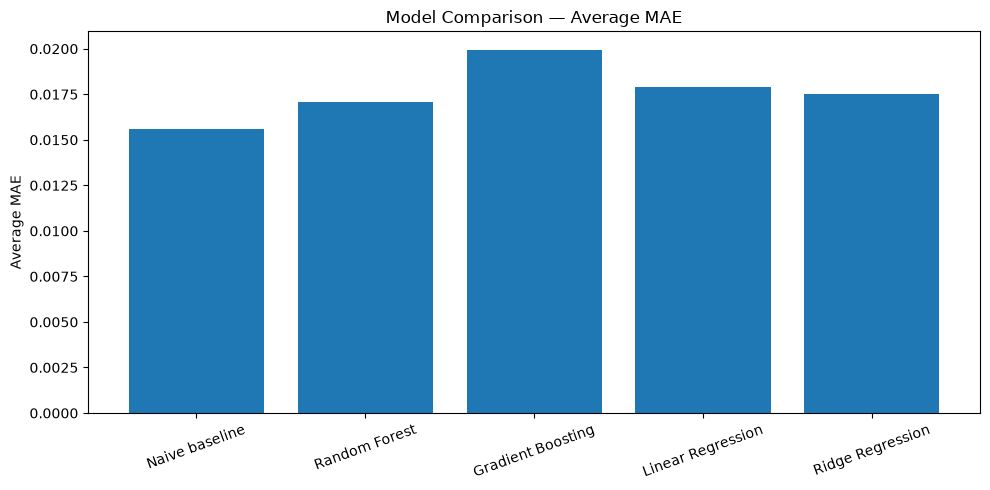

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["Avg MAE"]
)

plt.ylabel("Average MAE")
plt.title("Model Comparison — Average MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

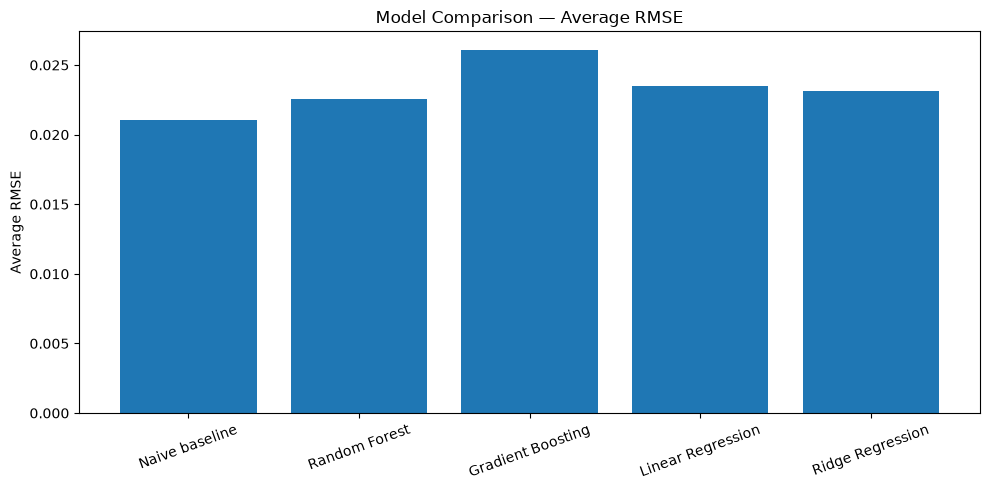

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["Avg RMSE"]
)

plt.ylabel("Average RMSE")
plt.title("Model Comparison — Average RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

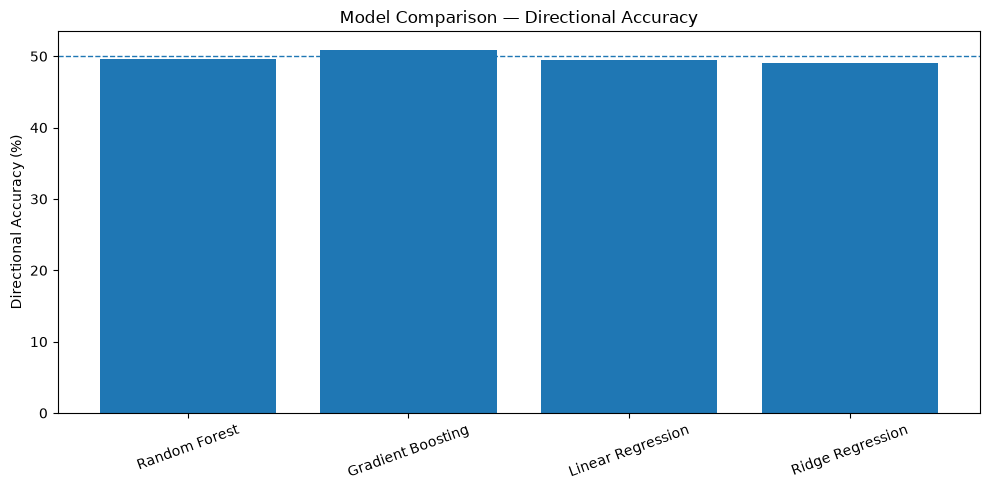

In [41]:
directional_results = comparison_results.dropna(
    subset=["Avg Directional Accuracy"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    directional_results["Model"],
    directional_results["Avg Directional Accuracy"] * 100
)

plt.ylabel("Directional Accuracy (%)")
plt.title("Model Comparison — Directional Accuracy")
plt.axhline(
    50,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [42]:
from IPython.display import Markdown, display

display(Markdown("""
## Directional Accuracy — Interpretation

Directional accuracy measures how often the model correctly predicts whether the next-day return is positive or negative.

The 50% reference line represents the approximate benchmark for random directional predictions.

### Results

| Model | Directional Accuracy |
|---|---:|
| Random Forest | 49.67% |
| Gradient Boosting | 50.94% |
| Linear Regression | 49.50% |
| Ridge Regression | 49.00% |

Gradient Boosting was slightly above the 50% reference level at 50.94%, while Random Forest, Linear Regression, and Ridge Regression were slightly below it.

Overall, the directional results remain close to 50%, indicating that the current feature set provides limited out-of-sample information for predicting next-day return direction.

This result should be interpreted within the limitations of the current dataset, features, model configurations, and walk-forward validation procedure.
"""))


## Directional Accuracy — Interpretation

Directional accuracy measures how often the model correctly predicts whether the next-day return is positive or negative.

The 50% reference line represents the approximate benchmark for random directional predictions.

### Results

| Model | Directional Accuracy |
|---|---:|
| Random Forest | 49.67% |
| Gradient Boosting | 50.94% |
| Linear Regression | 49.50% |
| Ridge Regression | 49.00% |

Gradient Boosting was slightly above the 50% reference level at 50.94%, while Random Forest, Linear Regression, and Ridge Regression were slightly below it.

Overall, the directional results remain close to 50%, indicating that the current feature set provides limited out-of-sample information for predicting next-day return direction.

This result should be interpreted within the limitations of the current dataset, features, model configurations, and walk-forward validation procedure.


In [43]:
comparison_results

,Model,Avg MAE,Avg RMSE,Avg Directional Accuracy
0,Naive baseline,0.015578,0.021048,NaN
1,Random Forest,0.017063,0.022595,0.496667
2,Gradient Boosting,0.019958,0.026115,0.509444
3,Linear Regression,0.017895,0.023480,0.495000
4,Ridge Regression,0.017530,0.023109,0.490000


In [44]:
from IPython.display import Markdown, display

display(Markdown("""
## Overall Model Comparison — Final Findings

The five forecasting approaches were evaluated using the same six-stock dataset, feature set, next-day return target, and walk-forward validation procedure.

### Key Findings

- The naive zero-return baseline produced the lowest average MAE and RMSE among the tested approaches.
- Random Forest, Gradient Boosting, Linear Regression, and Ridge Regression all produced higher average prediction errors than the naive baseline.
- Gradient Boosting achieved 50.94% directional accuracy, slightly above the 50% reference level.
- Random Forest achieved 49.67%, Linear Regression 49.50%, and Ridge Regression 49.00% directional accuracy.
- Overall directional accuracy remained close to 50%, indicating limited out-of-sample predictive signal for next-day return direction with the current feature set.

### Conclusion

The experiments provide a useful baseline for further development of AVA-AI. The current results suggest that additional feature engineering, longer historical datasets, alternative target definitions, model tuning, and potentially different forecasting horizons should be investigated before drawing stronger conclusions about predictive performance.

These findings describe the results of the current experiment and do not imply that machine-learning methods cannot be useful for financial forecasting under different datasets or methodologies.
"""))


## Overall Model Comparison — Final Findings

The five forecasting approaches were evaluated using the same six-stock dataset, feature set, next-day return target, and walk-forward validation procedure.

### Key Findings

- The naive zero-return baseline produced the lowest average MAE and RMSE among the tested approaches.
- Random Forest, Gradient Boosting, Linear Regression, and Ridge Regression all produced higher average prediction errors than the naive baseline.
- Gradient Boosting achieved 50.94% directional accuracy, slightly above the 50% reference level.
- Random Forest achieved 49.67%, Linear Regression 49.50%, and Ridge Regression 49.00% directional accuracy.
- Overall directional accuracy remained close to 50%, indicating limited out-of-sample predictive signal for next-day return direction with the current feature set.

### Conclusion

The experiments provide a useful baseline for further development of AVA-AI. The current results suggest that additional feature engineering, longer historical datasets, alternative target definitions, model tuning, and potentially different forecasting horizons should be investigated before drawing stronger conclusions about predictive performance.

These findings describe the results of the current experiment and do not imply that machine-learning methods cannot be useful for financial forecasting under different datasets or methodologies.


In [45]:
## Next Phase — Feature and Target Experiments

The initial walk-forward experiments show that the current feature set provides limited out-of-sample predictive signal for next-day returns.

The next phase will investigate whether predictive performance can be improved through:

1. Additional technical and market-derived features
2. Alternative target definitions
3. Feature scaling and transformation
4. Model hyperparameter tuning
5. Alternative forecasting horizons

Each experiment will use the same walk-forward validation framework so that results remain comparable with the established baseline models.

SyntaxError: invalid syntax (4034301485.py, line 3)

In [46]:
# Additional return-based features for experimentation

for ticker, df in stocks.items():
    df["return_lag2"] = df["return"].shift(2)
    df["return_lag3"] = df["return"].shift(3)
    df["return_lag10"] = df["return"].shift(10)

    df["rolling_return_5"] = df["return"].rolling(5).mean()
    df["rolling_return_10"] = df["return"].rolling(10).mean()

    df["price_vs_MA20"] = df["close"] / df["MA20"] - 1
    df["price_vs_MA50"] = df["close"] / df["MA50"] - 1

print("Additional features added.")

Additional features added.


In [47]:
expanded_feature_columns = feature_columns + [
    "return_lag2",
    "return_lag3",
    "return_lag10",
    "rolling_return_5",
    "rolling_return_10",
    "price_vs_MA20",
    "price_vs_MA50",
]

expanded_model_datasets = {}

for ticker, data in stocks.items():
    expanded_model_datasets[ticker] = (
        data[expanded_feature_columns + ["target_return"]]
        .dropna()
        .copy()
    )

for ticker, data in expanded_model_datasets.items():
    print(ticker, data.shape)

AAPL (450, 18)
AMZN (450, 18)
GOOGL (450, 18)
MSFT (450, 18)
NVDA (450, 18)
TSLA (450, 18)


In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

expanded_rf_results = []

for ticker, data in expanded_model_datasets.items():
    X = data[expanded_feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:
        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=8,
            min_samples_leaf=3
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    expanded_rf_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

expanded_rf_results_df = pd.DataFrame(expanded_rf_results)

print(expanded_rf_results_df)

print("\nOverall averages:")
print("MAE :", expanded_rf_results_df["MAE"].mean())
print("RMSE:", expanded_rf_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    expanded_rf_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.012352  0.016933              0.483333
1   AMZN  0.016667  0.023003              0.483333
2  GOOGL  0.016043  0.021438              0.483333
3   MSFT  0.013618  0.018907              0.503333
4   NVDA  0.018640  0.023631              0.493333
5   TSLA  0.024274  0.031144              0.460000

Overall averages:
MAE : 0.016932361926383022
RMSE: 0.022509310041021528
Directional Accuracy: 0.4844444444444444


In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

expanded_gb_results = []

for ticker, data in expanded_model_datasets.items():
    X = data[expanded_feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:
        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    expanded_gb_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

expanded_gb_results_df = pd.DataFrame(expanded_gb_results)

print(expanded_gb_results_df)

print("\nOverall averages:")
print("MAE :", expanded_gb_results_df["MAE"].mean())
print("RMSE:", expanded_gb_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    expanded_gb_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.014027  0.018713              0.446667
1   AMZN  0.019325  0.026097              0.490000
2  GOOGL  0.021624  0.027089              0.453333
3   MSFT  0.015268  0.021194              0.523333
4   NVDA  0.020462  0.026101              0.526667
5   TSLA  0.025704  0.033109              0.483333

Overall averages:
MAE : 0.01940168958959411
RMSE: 0.025383741776071802
Directional Accuracy: 0.4872222222222223


In [50]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

scaled_ridge_results = []

for ticker, data in expanded_model_datasets.items():
    X = data[expanded_feature_columns]
    y = data["target_return"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:
        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=1.0))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    scaled_ridge_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

scaled_ridge_results_df = pd.DataFrame(scaled_ridge_results)

print(scaled_ridge_results_df)

print("\nOverall averages:")
print("MAE :", scaled_ridge_results_df["MAE"].mean())
print("RMSE:", scaled_ridge_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    scaled_ridge_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.013285  0.017886              0.513333
1   AMZN  0.016055  0.022506              0.503333
2  GOOGL  0.017796  0.023521              0.436667
3   MSFT  0.013994  0.019299              0.426667
4   NVDA  0.020427  0.025440              0.510000
5   TSLA  0.024647  0.030855              0.500000

Overall averages:
MAE : 0.01770083927433557
RMSE: 0.023251213089632395
Directional Accuracy: 0.48166666666666663


In [51]:
## Experiment 3 — Feature Scaling with Ridge Regression

The expanded feature set was evaluated with Ridge Regression using standard feature scaling through a `StandardScaler` pipeline.

### Results

| Metric | Original Ridge Regression | Scaled + Expanded Features |
|---|---:|---:|
| Average MAE | 0.017530 | 0.017701 |
| Average RMSE | 0.023109 | 0.023251 |
| Directional Accuracy | 49.00% | 48.17% |

### Interpretation

Feature scaling combined with the expanded feature set did not improve the overall Ridge Regression results.

Average MAE and RMSE were slightly higher, while directional accuracy decreased from 49.00% to 48.17%.

This experiment suggests that feature scaling alone does not provide a clear performance improvement under the current target definition and walk-forward validation procedure.

SyntaxError: invalid syntax (3579029911.py, line 3)

In [52]:
# Create a 5-day forward return target

for ticker, df in stocks.items():
    df["target_return_5d"] = df["close"].shift(-5) / df["close"] - 1

print("5-day forward return target created.")

5-day forward return target created.


In [53]:
five_day_model_datasets = {}

for ticker, data in stocks.items():
    five_day_model_datasets[ticker] = (
        data[expanded_feature_columns + ["target_return_5d"]]
        .dropna()
        .copy()
    )

for ticker, data in five_day_model_datasets.items():
    print(ticker, data.shape)

AAPL (446, 18)
AMZN (446, 18)
GOOGL (446, 18)
MSFT (446, 18)
NVDA (446, 18)
TSLA (446, 18)


In [54]:
five_day_rf_results = []

for ticker, data in five_day_model_datasets.items():
    X = data[expanded_feature_columns]
    y = data["target_return_5d"]

    fold_mae = []
    fold_rmse = []
    fold_direction = []

    for train_end, test_start, test_end in walk_splits:
        # Keep the existing walk-forward structure,
        # but restrict it to the available 446 rows.
        if test_end > len(data):
            continue

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=8,
            min_samples_leaf=3
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_test, y_pred))
        )

        actual_direction = np.sign(y_test.values)
        predicted_direction = np.sign(y_pred)

        fold_direction.append(
            np.mean(actual_direction == predicted_direction)
        )

    five_day_rf_results.append({
        "ticker": ticker,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "Directional Accuracy": np.mean(fold_direction)
    })

five_day_rf_results_df = pd.DataFrame(five_day_rf_results)

print(five_day_rf_results_df)

print("\nOverall averages:")
print("MAE :", five_day_rf_results_df["MAE"].mean())
print("RMSE:", five_day_rf_results_df["RMSE"].mean())
print(
    "Directional Accuracy:",
    five_day_rf_results_df["Directional Accuracy"].mean()
)

  ticker       MAE      RMSE  Directional Accuracy
0   AAPL  0.038744  0.047656              0.487500
1   AMZN  0.053096  0.061635              0.495833
2  GOOGL  0.043567  0.056918              0.520833
3   MSFT  0.030989  0.037685              0.479167
4   NVDA  0.040183  0.051707              0.566667
5   TSLA  0.071140  0.088578              0.433333

Overall averages:
MAE : 0.04628638628940229
RMSE: 0.0573630159182685
Directional Accuracy: 0.49722222222222223


In [55]:
## Experiment 4 — 5-Day Forward Return Target

The prediction target was changed from the next-day return to the 5-day forward return:

`target_return_5d = close.shift(-5) / close - 1`

The expanded feature set was evaluated using the same Random Forest configuration and walk-forward validation procedure.

### Results

| Metric | 1-Day Target | 5-Day Target |
|---|---:|---:|
| Average MAE | 0.016932 | 0.046286 |
| Average RMSE | 0.022509 | 0.057363 |
| Directional Accuracy | 48.44% | 49.72% |

### Interpretation

Changing the prediction horizon from one day to five days increased both MAE and RMSE because the model is predicting a larger cumulative price movement over a longer horizon.

Directional accuracy was 49.72%, which remains close to 50%.

Therefore, extending the prediction horizon to five days did not produce a clear improvement in directional prediction under the current feature set and validation procedure.

This experiment suggests that changing the prediction horizon alone is not sufficient to produce a strong directional signal.

SyntaxError: invalid syntax (1839331617.py, line 3)

In [56]:
# Create binary direction target
for ticker, df in stocks.items():
    df["target_direction"] = (df["target_return"] > 0).astype(int)

print("Binary direction target created.")

# Check the distribution
for ticker, df in stocks.items():
    print(
        ticker,
        "Up:",
        (df["target_direction"] == 1).sum(),
        "Down:",
        (df["target_direction"] == 0).sum()
    )

Binary direction target created.
AAPL Up: 268 Down: 232
AMZN Up: 257 Down: 243
GOOGL Up: 261 Down: 239
MSFT Up: 262 Down: 238
NVDA Up: 263 Down: 237
TSLA Up: 250 Down: 250


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

classification_results = []

for ticker, data in stocks.items():
    # Use rows with complete expanded features and target
    model_data = (
        data[expanded_feature_columns + ["target_direction"]]
        .dropna()
        .copy()
    )

    X = model_data[expanded_feature_columns]
    y = model_data["target_direction"]

    fold_accuracy = []

    for train_end, test_start, test_end in walk_splits:
        if test_end > len(model_data):
            continue

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=8,
            min_samples_leaf=3
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_accuracy.append(
            accuracy_score(y_test, y_pred)
        )

    classification_results.append({
        "ticker": ticker,
        "Accuracy": np.mean(fold_accuracy)
    })

classification_results_df = pd.DataFrame(classification_results)

print(classification_results_df)

print("\nOverall average accuracy:")
print(
    classification_results_df["Accuracy"].mean()
)

  ticker  Accuracy
0   AAPL  0.483333
1   AMZN  0.516667
2  GOOGL  0.470000
3   MSFT  0.506667
4   NVDA  0.520000
5   TSLA  0.496667

Overall average accuracy:
0.4988888888888889


In [58]:
classification_baseline_results = []

for ticker, data in stocks.items():
    model_data = (
        data[expanded_feature_columns + ["target_direction"]]
        .dropna()
        .copy()
    )

    X = model_data[expanded_feature_columns]
    y = model_data["target_direction"]

    fold_accuracy = []

    for train_end, test_start, test_end in walk_splits:
        if test_end > len(model_data):
            continue

        y_train = y.iloc[:train_end]
        y_test = y.iloc[test_start:test_end]

        # Predict the most common class in the training data
        majority_class = y_train.mode()[0]

        y_pred = np.full(len(y_test), majority_class)

        fold_accuracy.append(
            accuracy_score(y_test, y_pred)
        )

    classification_baseline_results.append({
        "ticker": ticker,
        "Accuracy": np.mean(fold_accuracy)
    })

classification_baseline_results_df = pd.DataFrame(
    classification_baseline_results
)

print(classification_baseline_results_df)

print("\nOverall baseline accuracy:")
print(
    classification_baseline_results_df["Accuracy"].mean()
)

  ticker  Accuracy
0   AAPL  0.533333
1   AMZN  0.493333
2  GOOGL  0.520000
3   MSFT  0.503333
4   NVDA  0.503333
5   TSLA  0.466667

Overall baseline accuracy:
0.5033333333333333


In [59]:
from pathlib import Path

print("Raw data files:")
for file in sorted(Path("../data/raw").glob("*.csv")):
    print(file.name)

Raw data files:
AAPL_daily.csv
AMZN_daily.csv
GOOGL_daily.csv
MSFT_daily.csv
NVDA_daily.csv
TSLA_daily.csv


In [60]:
pooled_model_datasets = []

for ticker, data in stocks.items():
    temp = (
        data[expanded_feature_columns + ["target_direction"]]
        .dropna()
        .copy()
    )

    temp["ticker"] = ticker
    pooled_model_datasets.append(temp)

pooled_data = pd.concat(
    pooled_model_datasets,
    axis=0,
    ignore_index=True
)

print("Pooled dataset shape:", pooled_data.shape)
print("\nRows by ticker:")
print(pooled_data["ticker"].value_counts())

Pooled dataset shape: (2706, 19)

Rows by ticker:
ticker
AAPL     451
AMZN     451
GOOGL    451
MSFT     451
NVDA     451
TSLA     451
Name: count, dtype: int64


In [61]:
# Restore the date information for pooled modeling
pooled_model_datasets = []

for ticker, data in stocks.items():
    temp = (
        data[expanded_feature_columns + ["target_direction"]]
        .dropna()
        .copy()
    )

    temp["ticker"] = ticker
    temp["datetime"] = temp.index

    pooled_model_datasets.append(temp)

pooled_data = pd.concat(
    pooled_model_datasets,
    axis=0,
    ignore_index=True
)

pooled_data = pooled_data.sort_values(
    "datetime"
).reset_index(drop=True)

print("Pooled dataset shape:", pooled_data.shape)
print("\nDate range:")
print(pooled_data["datetime"].min(), "to", pooled_data["datetime"].max())

print("\nFirst 5 rows:")
print(pooled_data[["datetime", "ticker", "target_direction"]].head())

Pooled dataset shape: (2706, 20)

Date range:
2024-12-06 00:00:00 to 2026-09-25 00:00:00

First 5 rows:
    datetime ticker  target_direction
0 2024-12-06   AAPL                 1
1 2024-12-06   TSLA                 1
2 2024-12-06  GOOGL                 1
3 2024-12-06   AMZN                 0
4 2024-12-06   MSFT                 1


In [62]:
pooled_rf_results = []

# Use the same five chronological periods as the original experiment
unique_dates = sorted(pooled_data["datetime"].unique())

pooled_splits = [
    (unique_dates[150], unique_dates[210]),
    (unique_dates[210], unique_dates[270]),
    (unique_dates[270], unique_dates[330]),
    (unique_dates[330], unique_dates[390]),
]

for train_start_date, test_start_date in pooled_splits:

    train_data = pooled_data[
        pooled_data["datetime"] < test_start_date
    ]

    test_data = pooled_data[
        (pooled_data["datetime"] >= test_start_date) &
        (pooled_data["datetime"] < unique_dates[
            unique_dates.index(test_start_date) + 60
        ])
    ]

    X_train = train_data[expanded_feature_columns]
    y_train = train_data["target_direction"]

    X_test = test_data[expanded_feature_columns]
    y_test = test_data["target_direction"]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8,
        min_samples_leaf=3
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    pooled_rf_results.append(
        accuracy_score(y_test, y_pred)
    )

print("Fold accuracies:")
print(pooled_rf_results)

print("\nOverall pooled accuracy:")
print(np.mean(pooled_rf_results))

Fold accuracies:
[0.5277777777777778, 0.4666666666666667, 0.475, 0.4777777777777778]

Overall pooled accuracy:
0.4868055555555556


In [63]:
# Build a cross-stock market-context feature
context_data = pooled_data.copy()

# Recover each stock's current-day return
return_context = []

for ticker, data in stocks.items():
    temp = data[["return"]].copy()
    temp["ticker"] = ticker
    temp["datetime"] = temp.index
    return_context.append(temp)

returns_all = pd.concat(
    return_context,
    ignore_index=True
)

# Calculate the average return across all six stocks for each date
market_return = (
    returns_all
    .groupby("datetime")["return"]
    .mean()
    .rename("market_return")
)

context_data = context_data.merge(
    market_return,
    on="datetime",
    how="left"
)

# Remove the current stock's own return to avoid duplicating its information
context_data["other_stocks_return"] = (
    context_data["market_return"] * 6
    - context_data["return_lag1"]
) / 5

print(
    context_data[
        ["datetime", "ticker", "return_lag1", "other_stocks_return"]
    ].head(10)
)

    datetime ticker  return_lag1  other_stocks_return
0 2024-12-06   AAPL     0.000123             0.015582
1 2024-12-06   TSLA     0.032297             0.009147
2 2024-12-06  GOOGL    -0.009921             0.017591
3 2024-12-06   AMZN     0.010955             0.013415
4 2024-12-06   MSFT     0.011888             0.013229
5 2024-12-06   NVDA    -0.000551             0.015717
6 2024-12-09   TSLA     0.053398            -0.011231
7 2024-12-09  GOOGL     0.011990            -0.002950
8 2024-12-09   NVDA    -0.018061             0.003061
9 2024-12-09   AMZN     0.029381            -0.006428


In [64]:
# Correctly calculate the same-day return of the other five stocks

context_data = pooled_data.copy()

# Get current-day returns for each stock
return_context = []

for ticker, data in stocks.items():
    temp = data[["return"]].copy()
    temp["ticker"] = ticker
    temp["datetime"] = temp.index
    return_context.append(temp)

returns_all = pd.concat(
    return_context,
    ignore_index=True
)

# Total return across all six stocks for each date
daily_total_return = (
    returns_all
    .groupby("datetime")["return"]
    .sum()
    .rename("daily_total_return")
)

# Merge total return into pooled data
context_data = context_data.merge(
    daily_total_return,
    on="datetime",
    how="left"
)

# Merge each stock's own current-day return
context_data = context_data.merge(
    returns_all.rename(columns={"return": "own_return"})[
        ["datetime", "ticker", "own_return"]
    ],
    on=["datetime", "ticker"],
    how="left"
)

# Average return of the other five stocks
context_data["other_stocks_return"] = (
    context_data["daily_total_return"]
    - context_data["own_return"]
) / 5

print(
    context_data[
        ["datetime", "ticker", "own_return", "other_stocks_return"]
    ].head(10)
)

    datetime ticker  own_return  other_stocks_return
0 2024-12-06   AAPL   -0.000823             0.015771
1 2024-12-06   TSLA    0.053398             0.004927
2 2024-12-06  GOOGL    0.011990             0.013208
3 2024-12-06   AMZN    0.029381             0.009730
4 2024-12-06   MSFT    0.002146             0.015177
5 2024-12-06   NVDA   -0.018061             0.019219
6 2024-12-09   TSLA    0.001464            -0.000845
7 2024-12-09  GOOGL    0.003778            -0.001307
8 2024-12-09   NVDA   -0.025484             0.004545
9 2024-12-09   AMZN   -0.004140             0.000276


In [65]:
context_data["other_stocks_return_lag1"] = (
    context_data
    .groupby("ticker")["other_stocks_return"]
    .shift(1)
)

print(
    context_data[
        [
            "datetime",
            "ticker",
            "other_stocks_return",
            "other_stocks_return_lag1"
        ]
    ].head(15)
)

     datetime ticker  other_stocks_return  other_stocks_return_lag1
0  2024-12-06   AAPL             0.015771                       NaN
1  2024-12-06   TSLA             0.004927                       NaN
2  2024-12-06  GOOGL             0.013208                       NaN
3  2024-12-06   AMZN             0.009730                       NaN
4  2024-12-06   MSFT             0.015177                       NaN
5  2024-12-06   NVDA             0.019219                       NaN
6  2024-12-09   TSLA            -0.000845                  0.004927
7  2024-12-09  GOOGL            -0.001307                  0.013208
8  2024-12-09   NVDA             0.004545                  0.019219
9  2024-12-09   AMZN             0.000276                  0.009730
10 2024-12-09   MSFT            -0.001656                  0.015177
11 2024-12-09   AAPL            -0.003772                  0.015771
12 2024-12-10   NVDA             0.015615                  0.004545
13 2024-12-10   TSLA             0.004479       

In [66]:
context_feature_columns = expanded_feature_columns + [
    "other_stocks_return_lag1"
]

context_model_data = context_data.dropna(
    subset=context_feature_columns + ["target_direction"]
).copy()

unique_dates_context = sorted(
    context_model_data["datetime"].unique()
)

context_splits = [
    (150, 210),
    (210, 270),
    (270, 330),
    (330, 390),
]

context_rf_results = []

for train_start, test_start in context_splits:

    train_end_date = unique_dates_context[test_start]

    if test_start + 60 >= len(unique_dates_context):
        continue

    test_end_date = unique_dates_context[test_start + 60]

    train_data = context_model_data[
        context_model_data["datetime"] < train_end_date
    ]

    test_data = context_model_data[
        (context_model_data["datetime"] >= train_end_date) &
        (context_model_data["datetime"] < test_end_date)
    ]

    X_train = train_data[context_feature_columns]
    y_train = train_data["target_direction"]

    X_test = test_data[context_feature_columns]
    y_test = test_data["target_direction"]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8,
        min_samples_leaf=3
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    context_rf_results.append(
        accuracy_score(y_test, y_pred)
    )

print("Fold accuracies:")
print(context_rf_results)

print("\nOverall accuracy:")
print(np.mean(context_rf_results))

Fold accuracies:
[0.5472222222222223, 0.45, 0.4638888888888889]

Overall accuracy:
0.4870370370370371


In [67]:
from sklearn.preprocessing import OneHotEncoder

# Use the pooled dataset without the cross-stock feature for a clean comparison
identity_data = pooled_data.copy()

# One-hot encode ticker
ticker_dummies = pd.get_dummies(
    identity_data["ticker"],
    prefix="ticker",
    dtype=int
)

identity_data = pd.concat(
    [identity_data, ticker_dummies],
    axis=1
)

identity_feature_columns = expanded_feature_columns + list(
    ticker_dummies.columns
)

# Use chronological date-based splits
unique_dates_identity = sorted(
    identity_data["datetime"].unique()
)

identity_splits = [
    (150, 210),
    (210, 270),
    (270, 330),
    (330, 390),
]

identity_rf_results = []

for train_start, test_start in identity_splits:

    if test_start + 60 >= len(unique_dates_identity):
        continue

    train_end_date = unique_dates_identity[test_start]
    test_end_date = unique_dates_identity[test_start + 60]

    train_data = identity_data[
        identity_data["datetime"] < train_end_date
    ]

    test_data = identity_data[
        (identity_data["datetime"] >= train_end_date) &
        (identity_data["datetime"] < test_end_date)
    ]

    X_train = train_data[identity_feature_columns]
    y_train = train_data["target_direction"]

    X_test = test_data[identity_feature_columns]
    y_test = test_data["target_direction"]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8,
        min_samples_leaf=3
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    identity_rf_results.append(
        accuracy_score(y_test, y_pred)
    )

print("Fold accuracies:")
print(identity_rf_results)

print("\nOverall accuracy:")
print(np.mean(identity_rf_results))

Fold accuracies:
[0.5416666666666666, 0.4388888888888889, 0.45555555555555555, 0.4861111111111111]

Overall accuracy:
0.48055555555555557


In [68]:
for ticker, df in stocks.items():
    df["target_direction_05"] = (
        df["target_return"] > 0.005
    ).astype(int)

threshold_counts = {}

for ticker, df in stocks.items():
    counts = (
        df["target_direction_05"]
        .value_counts()
        .sort_index()
    )

    threshold_counts[ticker] = {
        "Down / <= 0.5%": counts.get(0, 0),
        "Up / > 0.5%": counts.get(1, 0)
    }

threshold_counts_df = pd.DataFrame(threshold_counts).T

print(threshold_counts_df)

       Down / <= 0.5%  Up / > 0.5%
AAPL              317          183
AMZN              309          191
GOOGL             295          205
MSFT              326          174
NVDA              277          223
TSLA              291          209


In [69]:
threshold_results = []

for ticker, data in stocks.items():

    model_data = (
        data[
            expanded_feature_columns +
            ["target_direction_05"]
        ]
        .dropna()
        .copy()
    )

    X = model_data[expanded_feature_columns]
    y = model_data["target_direction_05"]

    fold_accuracy = []

    for train_end, test_start, test_end in walk_splits:

        if test_end > len(model_data):
            continue

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=8,
            min_samples_leaf=3
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_accuracy.append(
            accuracy_score(y_test, y_pred)
        )

    threshold_results.append({
        "ticker": ticker,
        "Accuracy": np.mean(fold_accuracy)
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df)

print("\nOverall accuracy:")
print(threshold_results_df["Accuracy"].mean())

  ticker  Accuracy
0   AAPL  0.620000
1   AMZN  0.586667
2  GOOGL  0.566667
3   MSFT  0.616667
4   NVDA  0.573333
5   TSLA  0.533333

Overall accuracy:
0.5827777777777777


In [70]:
threshold_baseline_results = []

for ticker, data in stocks.items():

    model_data = (
        data[
            expanded_feature_columns +
            ["target_direction_05"]
        ]
        .dropna()
        .copy()
    )

    y = model_data["target_direction_05"]

    fold_accuracy = []

    for train_end, test_start, test_end in walk_splits:

        if test_end > len(model_data):
            continue

        y_train = y.iloc[:train_end]
        y_test = y.iloc[test_start:test_end]

        majority_class = y_train.mode()[0]

        y_pred = np.full(
            len(y_test),
            majority_class
        )

        fold_accuracy.append(
            accuracy_score(y_test, y_pred)
        )

    threshold_baseline_results.append({
        "ticker": ticker,
        "Accuracy": np.mean(fold_accuracy)
    })

threshold_baseline_df = pd.DataFrame(
    threshold_baseline_results
)

print(threshold_baseline_df)

print("\nOverall baseline accuracy:")
print(threshold_baseline_df["Accuracy"].mean())

  ticker  Accuracy
0   AAPL  0.636667
1   AMZN  0.630000
2  GOOGL  0.600000
3   MSFT  0.646667
4   NVDA  0.566667
5   TSLA  0.566667

Overall baseline accuracy:
0.6077777777777778


In [71]:
from sklearn.metrics import balanced_accuracy_score

threshold_balanced_results = []

for ticker, data in stocks.items():

    model_data = (
        data[
            expanded_feature_columns +
            ["target_direction_05"]
        ]
        .dropna()
        .copy()
    )

    X = model_data[expanded_feature_columns]
    y = model_data["target_direction_05"]

    fold_scores = []

    for train_end, test_start, test_end in walk_splits:

        if test_end > len(model_data):
            continue

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=8,
            min_samples_leaf=3
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_scores.append(
            balanced_accuracy_score(y_test, y_pred)
        )

    threshold_balanced_results.append({
        "ticker": ticker,
        "Balanced Accuracy": np.mean(fold_scores)
    })

threshold_balanced_df = pd.DataFrame(
    threshold_balanced_results
)

print(threshold_balanced_df)

print("\nOverall balanced accuracy:")
print(
    threshold_balanced_df["Balanced Accuracy"].mean()
)

  ticker  Balanced Accuracy
0   AAPL           0.489274
1   AMZN           0.478313
2  GOOGL           0.496594
3   MSFT           0.527937
4   NVDA           0.538664
5   TSLA           0.484861

Overall balanced accuracy:
0.5026072371530079


In [72]:
## Experiment 10 — Thresholded Return Classification

To test whether predicting only meaningful positive moves would improve classification, the target was changed from simple next-day direction to:

- Class 1: next-day return > +0.5%
- Class 0: next-day return <= +0.5%

A Random Forest classifier was evaluated using the expanded feature set and walk-forward validation.

The raw classification accuracy was **58.28%**, compared with a majority-class baseline of **60.78%**. Therefore, the Random Forest did not outperform the simple baseline.

Because the thresholded target is imbalanced, balanced accuracy was also evaluated. The Random Forest achieved an overall balanced accuracy of **50.26%**, which is effectively close to chance-level performance.

Per-stock balanced accuracy:

- AAPL: 48.93%
- AMZN: 47.83%
- GOOGL: 49.66%
- MSFT: 52.79%
- NVDA: 53.87%
- TSLA: 48.49%

These results indicate that the apparent improvement in raw accuracy was largely driven by class imbalance rather than reliable predictive signal.

The thresholded classification experiment therefore does not provide evidence that the expanded technical features can reliably predict whether the next-day return will exceed +0.5%.

SyntaxError: invalid syntax (502593891.py, line 3)

In [73]:
from sklearn.metrics import precision_score, recall_score, balanced_accuracy_score

threshold_probability_results = []

probability_thresholds = [0.50, 0.60, 0.70]

for probability_threshold in probability_thresholds:

    fold_metrics = []

    for ticker, data in stocks.items():

        model_data = (
            data[
                expanded_feature_columns +
                ["target_direction"]
            ]
            .dropna()
            .copy()
        )

        X = model_data[expanded_feature_columns]
        y = model_data["target_direction"]

        for train_end, test_start, test_end in walk_splits:

            if test_end > len(model_data):
                continue

            X_train = X.iloc[:train_end]
            y_train = y.iloc[:train_end]

            X_test = X.iloc[test_start:test_end]
            y_test = y.iloc[test_start:test_end]

            model = RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=8,
                min_samples_leaf=3
            )

            model.fit(X_train, y_train)

            probabilities = model.predict_proba(X_test)[:, 1]

            y_pred = (
                probabilities >= probability_threshold
            ).astype(int)

            fold_metrics.append({
                "Threshold": probability_threshold,
                "Precision": precision_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),
                "Recall": recall_score(
                    y_test,
                    y_pred,
                    zero_division=0
                ),
                "Balanced Accuracy": balanced_accuracy_score(
                    y_test,
                    y_pred
                )
            })

threshold_probability_df = pd.DataFrame(
    fold_metrics
)

print(
    threshold_probability_df
    .groupby("Threshold")
    .mean()
)

           Precision    Recall  Balanced Accuracy
Threshold                                        
0.7         0.198535  0.019988           0.503069


In [74]:
print(
    threshold_probability_df
    .groupby("Threshold")[["Precision", "Recall", "Balanced Accuracy"]]
    .mean()
    .round(4)
)

           Precision  Recall  Balanced Accuracy
Threshold                                      
0.7           0.1985    0.02             0.5031


In [75]:
## Experiment 11 — High-Confidence Classification Threshold

A high-confidence classification threshold of 0.70 was tested using Random Forest predicted probabilities. The objective was to determine whether restricting positive predictions to cases where the model assigned at least 70% probability would produce more reliable signals.

The resulting average metrics were:

- Precision: **19.85%**
- Recall: **2.00%**
- Balanced Accuracy: **50.31%**

The high threshold substantially reduced the number of positive predictions, resulting in very low recall. More importantly, balanced accuracy remained close to chance level.

This indicates that increasing the prediction-confidence threshold did not reveal a meaningful predictive signal in the current feature set.

The experiment therefore does not support using a high-confidence probability threshold as a reliable improvement to the forecasting model.

SyntaxError: invalid syntax (1225919663.py, line 3)

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score

logistic_results = []

for ticker, data in stocks.items():

    model_data = (
        data[
            expanded_feature_columns +
            ["target_direction"]
        ]
        .dropna()
        .copy()
    )

    X = model_data[expanded_feature_columns]
    y = model_data["target_direction"]

    fold_accuracy = []
    fold_balanced_accuracy = []

    for train_end, test_start, test_end in walk_splits:

        if test_end > len(model_data):
            continue

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]

        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("logistic", LogisticRegression(
                max_iter=1000,
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        fold_accuracy.append(
            accuracy_score(y_test, y_pred)
        )

        fold_balanced_accuracy.append(
            balanced_accuracy_score(y_test, y_pred)
        )

    logistic_results.append({
        "ticker": ticker,
        "Accuracy": np.mean(fold_accuracy),
        "Balanced Accuracy": np.mean(
            fold_balanced_accuracy
        )
    })

logistic_results_df = pd.DataFrame(logistic_results)

print(logistic_results_df)

print("\nOverall accuracy:")
print(logistic_results_df["Accuracy"].mean())

print("\nOverall balanced accuracy:")
print(
    logistic_results_df["Balanced Accuracy"].mean()
)

  ticker  Accuracy  Balanced Accuracy
0   AAPL  0.476667           0.488785
1   AMZN  0.510000           0.526351
2  GOOGL  0.453333           0.495024
3   MSFT  0.483333           0.485697
4   NVDA  0.523333           0.524442
5   TSLA  0.516667           0.526853

Overall accuracy:
0.4938888888888889

Overall balanced accuracy:
0.5078585589277111
